# CN vs. EMCI Classification — Resting-State fMRI Connectivity Pipeline

**Cohort:** 433 ADNI subjects (219 CN / 214 EMCI), AAL-116 parcellation, tangent-space functional connectivity, LinearSVC.

This notebook is organized into numbered sections. Cells are numbered `[n]` in their first line for reference. Run sections top to bottom; Sections 1–3 rebuild everything needed after a runtime disconnect.

**Validation summary**
| Protocol | Balanced accuracy | Controls for |
|---|---|---|
| Leakage-free repeated holdout | 0.711 ± 0.049 | tangent-reference leakage |
| Repeated site-aware CV | see Section 7 | scanner/site generalization |


## 1 · Setup & configuration

In [ ]:
# [1]
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [ ]:
# [2]
# Install required packages
import subprocess, sys

packages = [
    'nilearn',
    'nibabel',
    'scipy',
    'scikit-learn',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'requests',
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)
    print(f'  \u2713 {pkg}')

print('\nAll packages installed.')

  ✓ nilearn
  ✓ nibabel
  ✓ scipy
  ✓ scikit-learn
  ✓ pandas
  ✓ numpy
  ✓ matplotlib
  ✓ seaborn
  ✓ requests

All packages installed.


In [ ]:
# [3]
# Core imports
import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

from sklearn.svm import LinearSVC
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_val_predict, permutation_test_score
)
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
print('All imports successful.')

All imports successful.


In [ ]:
# [4]
# ── Drive paths ──────────────────────────────────────────────────────────────
DRIVE_ROOT = '/content/drive/MyDrive'
REG_ROOT   = f'{DRIVE_ROOT}/registered_fmri'             # STEP1 output root

# Per-session centroid-offset quality CSVs produced by STEP1 (CELL 18)
N_SESSIONS        = 3
QUALITY_CSV_PATHS = [f'{REG_ROOT}/centroid_quality_session_{i}.csv' for i in range(N_SESSIONS)]

# Merged subject table (group label, original_id, etc.) — built in STEP1 CELL 5
SUBJECTS_TABLE_PATH = f'{DRIVE_ROOT}/subjects_df_v2.csv'

# MNI template used during registration — its affine is the "true" affine for
# every registered file (STEP1's saved affines only encode spacing+origin)
MNI_TEMPLATE_PATH = f'{REG_ROOT}/MNI152_T1_2mm_brain.nii.gz'

# Resumable per-subject ROI-timeseries cache — shared with STEP2, so anything
# already extracted there is reused here for free
TIMESERIES_CACHE_DIR = f'{REG_ROOT}/timeseries_cache'
Path(TIMESERIES_CACHE_DIR).mkdir(parents=True, exist_ok=True)

# Where this notebook writes its own outputs
OUTPUT_DIR  = f'{REG_ROOT}/classifier_v2_outputs'
RESULTS_DIR = f'{OUTPUT_DIR}/results'
for d in [OUTPUT_DIR, RESULTS_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

FEATURE_CHECKPOINT_PATH = f'{OUTPUT_DIR}/feature_checkpoint.npz'

# ── Quality CSV column names ─────────────────────────────────────────────────
# Adjust these four if your actual CSV headers differ.
COL_OFFSET = 'xy_offset_mm'
COL_TIER   = 'tier'
COL_METHOD = 'method'
COL_ID     = 'original_id'
COL_GROUP  = 'group'
QUALIFYING_TIERS = ['GOOD', 'MARGINAL']

# The 4 subjects previously identified as persistent POOR-quality stragglers.
# QUALIFYING_TIERS should already exclude these (they're POOR), but they're
# listed explicitly here as documentation and as a defensive double-check.
KNOWN_POOR_STRAGGLERS = ['032_S_2119', '068_S_4332', '003_S_4288', '003_S_4350']

# ── Atlas configuration ──────────────────────────────────────────────────────
# AAL-116 (the classic benchmark atlas). nilearn >=0.13 changed the default
# `version` to '3v2' (167 regions) — must pin 'SPM12' explicitly or features
# become non-comparable to the established benchmark.
ATLAS_VERSION = 'SPM12'

# ── Extraction parameters ────────────────────────────────────────────────────
DUMMY_SCANS = 4      # volumes discarded at the start (scanner stabilization)
MAX_VOLUMES = 180    # cap per subject for extraction speed (matches STEP2)
DEFAULT_TR  = 3.0    # fallback TR (s) if header TR can't be read reliably
LOW_PASS    = 0.1    # bandpass upper bound (Hz)
HIGH_PASS   = 0.01   # bandpass lower bound (Hz)

# ── ML parameters ────────────────────────────────────────────────────────────
SEED          = 42
CV_FOLDS      = 5
N_PERMUTATIONS = 1000

np.random.seed(SEED)

print('Configuration set.')
print(f'REG_ROOT              : {REG_ROOT}')
print(f'Timeseries cache       : {TIMESERIES_CACHE_DIR}')
print(f'Atlas                  : AAL ({ATLAS_VERSION}, expect 116 regions)')
print(f'Quality tiers accepted  : {QUALIFYING_TIERS}')

Configuration set.
REG_ROOT              : /content/drive/MyDrive/registered_fmri
Timeseries cache       : /content/drive/MyDrive/registered_fmri/timeseries_cache
Atlas                  : AAL (SPM12, expect 116 regions)
Quality tiers accepted  : ['GOOD', 'MARGINAL']


## 2 · Build the cohort
Load per-session QC results, keep GOOD/MARGINAL tiers, attach labels, derive site.

In [ ]:
# [5]
# ── Load and merge per-session quality CSVs ──────────────────────────────────
quality_frames = []
for i, path in enumerate(QUALITY_CSV_PATHS):
    if not Path(path).exists():
        print(f'  \u26a0 Session {i} quality CSV not found, skipping: {path}')
        continue
    df = pd.read_csv(path)
    df['session'] = i
    quality_frames.append(df)
    print(f'  Session {i}: {len(df)} rows  ({path})')

if not quality_frames:
    raise FileNotFoundError(
        'No quality CSVs were found. Check QUALITY_CSV_PATHS in the '
        'Configuration cell against what actually exists under REG_ROOT.'
    )

quality_all = pd.concat(quality_frames, ignore_index=True)
print(f'\nTotal rows across all sessions: {len(quality_all)}')
print(f'Columns: {list(quality_all.columns)}')

# ── Dedup: keep best (lowest-offset) result per subject ──────────────────────
quality_all = quality_all.sort_values(COL_OFFSET, ascending=True)
quality_dedup = quality_all.drop_duplicates(subset=COL_ID, keep='first').reset_index(drop=True)

print(f'\nUnique subjects after dedup : {len(quality_dedup)}')
print(f'Quality tier breakdown:')
print(quality_dedup[COL_TIER].value_counts().to_string())

  Session 0: 160 rows  (/content/drive/MyDrive/registered_fmri/centroid_quality_session_0.csv)
  Session 1: 173 rows  (/content/drive/MyDrive/registered_fmri/centroid_quality_session_1.csv)
  Session 2: 148 rows  (/content/drive/MyDrive/registered_fmri/centroid_quality_session_2.csv)

Total rows across all sessions: 481
Columns: ['original_id', 'group', 'method', 'xy_offset_mm', 'tier', 'session']

Unique subjects after dedup : 436
Quality tier breakdown:
tier
GOOD        420
MARGINAL     13
POOR          3


In [ ]:
# [6]
# ── Filter to qualifying tiers, attach group label and filepath ─────────────
qualifying = quality_dedup[quality_dedup[COL_TIER].isin(QUALIFYING_TIERS)].copy()

# Only load the subjects table if the quality CSV doesn't already carry the
# group label itself (yours does, via the 'group' column, so this is skipped).
if COL_GROUP not in qualifying.columns:
    subjects_df_v2 = pd.read_csv(SUBJECTS_TABLE_PATH)
    qualifying = qualifying.merge(
        subjects_df_v2[[COL_ID, COL_GROUP]], on=COL_ID, how='left'
    )

qualifying['label_encoded'] = (qualifying[COL_GROUP] == 'EMCI').astype(int)
qualifying['filepath'] = qualifying.apply(
    lambda r: f"{REG_ROOT}/{r[COL_GROUP]}/{r[COL_ID]}_registered_fmri.nii.gz",
    axis=1,
)

# Drop any rows whose registered file doesn't actually exist on disk
exists_mask = qualifying['filepath'].apply(lambda p: Path(p).exists())
missing_files = qualifying.loc[~exists_mask, COL_ID].tolist()
cohort_df = qualifying.loc[exists_mask].reset_index(drop=True)

# Defensive check — confirm none of the known stragglers slipped through
present_stragglers = set(KNOWN_POOR_STRAGGLERS) & set(cohort_df[COL_ID])
if present_stragglers:
    print(f'  ⚠ Known POOR stragglers unexpectedly passed the tier filter: {present_stragglers}')
else:
    print('  ✓ Known POOR stragglers correctly excluded by the tier filter.')

print(f'\n{"="*55}')
print('COHORT SUMMARY')
print(f'{"="*55}')
print(f'Qualifying (GOOD/MARGINAL) : {len(qualifying)}')
print(f'Missing registered file    : {len(missing_files)}')
print(f'Final cohort                : {len(cohort_df)}')
print(f'\nBy group:')
print(cohort_df[COL_GROUP].value_counts().to_string())
if COL_METHOD in cohort_df.columns:
    print(f'\nBy registration method:')
    print(cohort_df[COL_METHOD].value_counts().to_string())
if missing_files:
    print(f'\nMissing files (first 10): {missing_files[:10]}')

  ⚠ Known POOR stragglers unexpectedly passed the tier filter: {'003_S_4350'}

COHORT SUMMARY
Qualifying (GOOD/MARGINAL) : 433
Missing registered file    : 0
Final cohort                : 433

By group:
group
CN      219
EMCI    214

By registration method:
method
Direct_EPI_MNI    279
T1w_mediated      139
unknown            15


In [ ]:
# [7]
# Derive site from the ADNI subject ID (first block, e.g. 002_S_1280 → "002")
cohort_df['site'] = cohort_df[COL_ID].str.split('_').str[0]

# 1. How many subjects per site?
print(cohort_df['site'].value_counts().to_string())

# 2. CN/EMCI balance within each site
print(pd.crosstab(cohort_df['site'], cohort_df[COL_GROUP]).to_string())

site
021    27
035    26
002    26
073    25
003    22
014    19
027    15
011    14
007    14
023    13
020    12
032    11
018    11
031    11
006    10
009    10
013    10
024     9
070     9
029     8
082     8
012     8
099     8
128     7
100     7
130     7
067     6
137     6
153     6
005     6
022     5
019     5
036     5
116     4
941     4
068     4
041     4
010     4
123     3
053     3
141     3
016     3
129     3
094     2
136     2
135     1
033     1
037     1
098     1
052     1
126     1
109     1
114     1
group  CN  EMCI
site           
002    19     7
003    22     0
005     5     1
006     9     1
007    14     0
009     5     5
010     4     0
011    10     4
012     3     5
013     5     5
014    17     2
016     2     1
018     5     6
019     3     2
020    11     1
021    20     7
022     2     3
023     6     7
024     0     9
027     7     8
029     4     4
031     4     7
032    11     0
033     1     0
035    26     0
036     3     2
037     0     1
0

In [ ]:
# [8]
# ── Dataset overview: cohort composition ─────────────────────────────────────
print(f'{"="*60}')
print('DATASET OVERVIEW')
print(f'{"="*60}\n')

n_total = len(cohort_df)
print(f'Total subjects in final cohort : {n_total}')

group_counts = cohort_df[COL_GROUP].value_counts()
print(f'\nGroup balance:')
for g, n in group_counts.items():
    print(f'  {g:<6}: {n:>4}  ({n / n_total:.1%})')

if COL_METHOD in cohort_df.columns:
    print(f'\nRegistration method breakdown:')
    method_counts = cohort_df[COL_METHOD].value_counts()
    for m, n in method_counts.items():
        print(f'  {m:<16}: {n:>4}  ({n / n_total:.1%})')

    print(f'\nRegistration method by group:')
    print(pd.crosstab(cohort_df[COL_GROUP], cohort_df[COL_METHOD]).to_string())

print(f'\nCentroid-offset QC metric ({COL_OFFSET}), by group:')
print(
    cohort_df.groupby(COL_GROUP)[COL_OFFSET]
    .describe()[['count', 'mean', 'std', 'min', 'max']]
    .round(3)
    .to_string()
)

# Quality tier composition within the final cohort (GOOD vs MARGINAL — POOR
# was already excluded upstream in Section 3)
print(f'\nQuality tier composition (within final cohort):')
print(cohort_df[COL_TIER].value_counts().to_string())

# ── Optional: pull in demographic columns if they exist on the subjects
# table (age / sex / site are common ADNI fields). Best-effort: if
# subjects_df_v2.csv doesn't carry these columns, this just notes that and
# moves on rather than failing.
demo_cols_wanted = ['age', 'sex', 'site', 'AGE', 'SEX', 'SITE', 'PTGENDER', 'PTAGE']
try:
    subjects_df_v2 = pd.read_csv(SUBJECTS_TABLE_PATH)
    found_demo_cols = [c for c in demo_cols_wanted if c in subjects_df_v2.columns]
    if found_demo_cols:
        demo_merge = cohort_df[[COL_ID, COL_GROUP]].merge(
            subjects_df_v2[[COL_ID] + found_demo_cols], on=COL_ID, how='left'
        )
        print(f'\nDemographic columns found on subjects table: {found_demo_cols}')
        for col in found_demo_cols:
            print(f'\n{col} by group:')
            if pd.api.types.is_numeric_dtype(demo_merge[col]):
                print(
                    demo_merge.groupby(COL_GROUP)[col]
                    .describe()[['count', 'mean', 'std', 'min', 'max']]
                    .round(2)
                    .to_string()
                )
            else:
                print(pd.crosstab(demo_merge[COL_GROUP], demo_merge[col]).to_string())
    else:
        print(f'\nNo demographic columns (age/sex/site) found on {SUBJECTS_TABLE_PATH}.')
        print('Add them to subjects_df_v2.csv and re-run this cell if you want them here.')
except Exception as e:
    print(f'\nCould not load subjects table for demographic overview: {e}')


DATASET OVERVIEW

Total subjects in final cohort : 433

Group balance:
  CN    :  219  (50.6%)
  EMCI  :  214  (49.4%)

Registration method breakdown:
  Direct_EPI_MNI  :  279  (64.4%)
  T1w_mediated    :  139  (32.1%)
  unknown         :   15  (3.5%)

Registration method by group:
method  Direct_EPI_MNI  T1w_mediated  unknown
group                                        
CN                 139            65       15
EMCI               140            74        0

Centroid-offset QC metric (xy_offset_mm), by group:
       count   mean    std   min    max
group                                  
CN     219.0  2.496  2.103  0.11  11.77
EMCI   214.0  2.183  2.051  0.05  14.36

Quality tier composition (within final cohort):
tier
GOOD        420
MARGINAL     13

Could not load subjects table for demographic overview: [Errno 2] No such file or directory: '/content/drive/MyDrive/subjects_df_v2.csv'


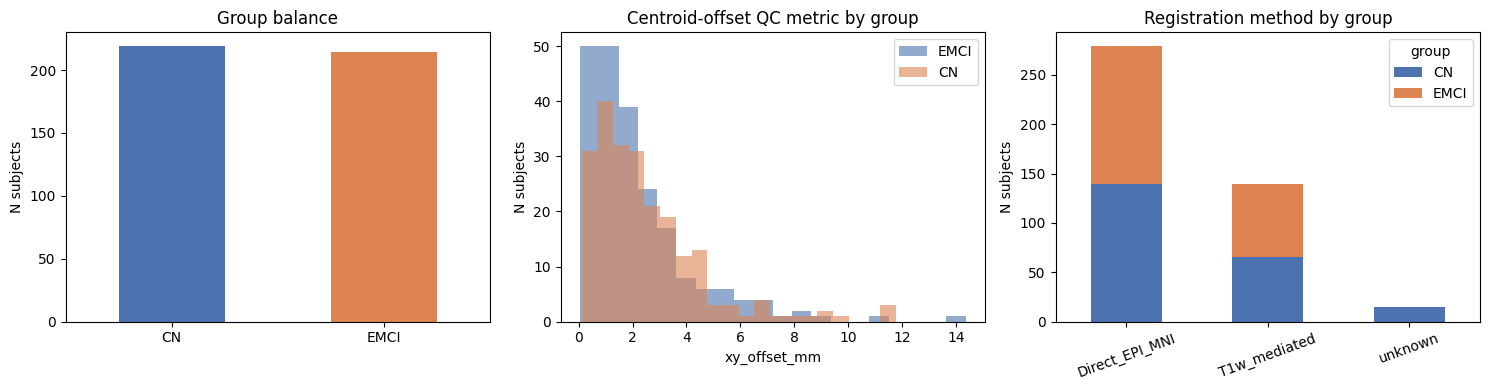

In [ ]:
# [9]
# ── Dataset overview: plots ───────────────────────────────────────────────────
n_panels = 3 if COL_METHOD in cohort_df.columns else 2
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))

group_levels = list(cohort_df[COL_GROUP].unique())
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Group balance
cohort_df[COL_GROUP].value_counts().plot(kind='bar', ax=axes[0], color=palette[:len(group_levels)])
axes[0].set_title('Group balance')
axes[0].set_xlabel('')
axes[0].set_ylabel('N subjects')
axes[0].tick_params(axis='x', rotation=0)

# Centroid-offset distribution by group
for g, color in zip(group_levels, palette):
    axes[1].hist(
        cohort_df.loc[cohort_df[COL_GROUP] == g, COL_OFFSET],
        bins=20, alpha=0.6, label=g, color=color,
    )
axes[1].set_title('Centroid-offset QC metric by group')
axes[1].set_xlabel(COL_OFFSET)
axes[1].set_ylabel('N subjects')
axes[1].legend()

if COL_METHOD in cohort_df.columns:
    pd.crosstab(cohort_df[COL_METHOD], cohort_df[COL_GROUP]).plot(
        kind='bar', stacked=True, ax=axes[2], color=palette[:len(group_levels)]
    )
    axes[2].set_title('Registration method by group')
    axes[2].set_xlabel('')
    axes[2].set_ylabel('N subjects')
    axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## 3 · Atlas & feature extraction
Fetch AAL-116 (SPM12), extract ROI timeseries, build tangent-space connectivity features.

In [ ]:
# [10]
# ── Fetch AAL-SPM12 atlas, working around an SSL verification issue ─────────
# nilearn's downloader uses `requests` internally, not `urllib` — patching
# ssl._create_default_https_context has no effect. The actual fix is to
# monkeypatch requests.Session.send to force verify=False, only for the
# duration of this fetch, then restore it.
import requests

_original_send = requests.Session.send

def _send_no_verify(self, request, **kwargs):
    kwargs['verify'] = False
    return _original_send(self, request, **kwargs)

requests.Session.send = _send_no_verify
try:
    aal = datasets.fetch_atlas_aal(version=ATLAS_VERSION)
finally:
    requests.Session.send = _original_send

atlas_img    = aal['maps']
atlas_labels = aal['labels']

print(f'Atlas fetched: {atlas_img}')
print(f'Label list length: {len(atlas_labels)}')

[fetch_atlas_aal] Dataset directory found: /root/nilearn_data/aal_SPM12

Atlas fetched: /root/nilearn_data/aal_SPM12/aal/atlas/AAL.nii
Label list length: 117


In [ ]:
# [11]
# ── Verify atlas correctness by inspecting the actual image, not the label
# list length — nilearn versions inconsistently include/exclude a
# 'Background' entry in `labels`, so that length alone isn't reliable.
atlas_check = nib.load(atlas_img)
unique_vals = np.unique(atlas_check.get_fdata())
n_real_regions = int((unique_vals != 0).sum())

print(f'Atlas shape       : {atlas_check.shape}')
print(f'Voxel size        : {atlas_check.header.get_zooms()[:3]}')
print(f'Non-zero regions  : {n_real_regions}')

if n_real_regions != 116:
    print(f'  \u26a0 Expected 116 non-zero regions for AAL/SPM12, got {n_real_regions}. '
          f'Double-check ATLAS_VERSION.')
else:
    print('  \u2713 Confirmed 116 real regions (AAL/SPM12).')

Atlas shape       : (91, 109, 91)
Voxel size        : (np.float32(2.0), np.float32(2.0), np.float32(2.0))
Non-zero regions  : 116
  ✓ Confirmed 116 real regions (AAL/SPM12).


In [ ]:
# [12]
# ── Helper functions ──────────────────────────────────────────────────────────

def get_tr_from_header(img, default_tr=DEFAULT_TR):
    """Read TR from a NIfTI header (pixdim[4]), with sanity bounds."""
    try:
        zooms = img.header.get_zooms()
        if len(zooms) >= 4:
            tr = float(zooms[3])
            if tr > 100:
                tr = tr / 1000.0   # ms -> seconds
            if 0.1 <= tr <= 10.0:
                return tr
    except Exception:
        pass
    return default_tr


def extract_roi_timeseries(row, atlas_img, template_affine, cache_dir):
    """
    Load a subject's registered fMRI, fix its affine, extract AAL-116 ROI
    timeseries, and cache the result. Returns (timeseries, info).
    """
    cache_path = Path(cache_dir) / f"{row[COL_ID]}.npy"

    if cache_path.exists():
        try:
            return np.load(str(cache_path)), {'cached': True}
        except Exception:
            pass  # corrupt cache — fall through and re-extract

    try:
        img = nib.load(row['filepath'])
        if len(img.shape) != 4:
            return None, {'error': 'Not a 4D image'}

        T = img.shape[3]
        if T < 20:
            return None, {'error': f'Too few volumes: {T}'}

        tr = get_tr_from_header(img)

        # Read only as many volumes as we'll actually use
        n_to_read = min(T, DUMMY_SCANS + MAX_VOLUMES)
        data = np.asarray(img.dataobj[..., :n_to_read], dtype=np.float32)

        n_skip = min(DUMMY_SCANS, n_to_read // 10)  # never skip more than 10%
        data = data[..., n_skip:]

        fixed_img = nib.Nifti1Image(data, template_affine)

        masker = NiftiLabelsMasker(
            labels_img  = atlas_img,
            standardize = True,
            detrend     = True,
            low_pass    = LOW_PASS,
            high_pass   = HIGH_PASS,
            t_r         = tr,
            verbose     = 0,
        )
        timeseries = masker.fit_transform(fixed_img)

        if timeseries.shape[0] < 20:
            return None, {'error': f'Timeseries too short: {timeseries.shape[0]}'}

        timeseries = timeseries.astype(np.float32)
        np.save(str(cache_path), timeseries)

        return timeseries, {
            'cached': False,
            'n_volumes_used': int(timeseries.shape[0]),
            'tr': tr,
        }

    except Exception as e:
        return None, {'error': str(e)}


print('Helper functions defined.')

Helper functions defined.


In [ ]:
# [13]
# ── Run extraction for the whole cohort ──────────────────────────────────────
# Safe to interrupt and re-run: anything already in timeseries_cache/ is
# reused instead of re-extracted, whether it was produced by this notebook or
# another one.

template_affine = nib.load(MNI_TEMPLATE_PATH).affine

extraction_log = []
n_from_cache   = 0
n_extracted    = 0

for _, row in tqdm(cohort_df.iterrows(), total=len(cohort_df), desc='Extracting timeseries'):
    ts, info = extract_roi_timeseries(row, atlas_img, template_affine, TIMESERIES_CACHE_DIR)

    info['original_id'] = row[COL_ID]
    info['group']       = row[COL_GROUP]
    extraction_log.append(info)

    if ts is None:
        print(f"  \u2717 {row[COL_ID]} | {info.get('error', 'unknown error')}")
    elif info.get('cached'):
        n_from_cache += 1
    else:
        n_extracted += 1

print(f'\n{"-"*55}')
print(f'From cache  : {n_from_cache}')
print(f'Newly extracted : {n_extracted}')
print(f'Failed      : {sum(1 for r in extraction_log if "error" in r)}')

Extracting timeseries:  10%|▉         | 43/433 [00:00<00:00, 426.37it/s]

  ✗ 128_S_5066 | Too few volumes: 10


Extracting timeseries: 100%|██████████| 433/433 [00:01<00:00, 230.08it/s]


-------------------------------------------------------
From cache  : 432
Newly extracted : 0
Failed      : 1


In [ ]:
# [14]
# ── Extraction failures report ────────────────────────────────────────────────
failures = [r for r in extraction_log if 'error' in r]

if failures:
    print(f'{len(failures)} subject(s) failed extraction:')
    for r in failures:
        print(f"  {r['original_id']} ({r['group']}) | {r['error']}")
else:
    print('No extraction failures.')

# Subjects that failed are simply absent from timeseries_cache/, so the next
# cell (which only loads what's actually cached) will naturally exclude them.

1 subject(s) failed extraction:
  128_S_5066 (EMCI) | Too few volumes: 10


### 3.1 · Assemble feature matrix
Builds `timeseries_list`, `cohort_final`, `X`, `y`, and `site_groups` used by all validation below.

In [ ]:
# [15]
timeseries_list = []
valid_rows      = []

for _, row in cohort_df.iterrows():
    cache_path = Path(TIMESERIES_CACHE_DIR) / f"{row[COL_ID]}.npy"
    if not cache_path.exists():
        continue
    ts = np.load(str(cache_path))
    if ts.shape[0] < 20:
        continue
    timeseries_list.append(ts)
    valid_rows.append(row)

cohort_final = pd.DataFrame(valid_rows).reset_index(drop=True)

conn_measure = ConnectivityMeasure(kind='tangent', vectorize=True, discard_diagonal=True)
X = conn_measure.fit_transform(timeseries_list)
y = cohort_final['label_encoded'].values

print(f'Final usable cohort : {len(cohort_final)} / {len(cohort_df)} attempted')
print(f'Feature matrix       : {X.shape}')
print(f'CN  (label 0)        : {(y == 0).sum()}')
print(f'EMCI (label 1)       : {(y == 1).sum()}')

np.savez(
    FEATURE_CHECKPOINT_PATH,
    X=X, y=y,
    sids=cohort_final[COL_ID].values,
    methods=cohort_final[COL_METHOD].values if COL_METHOD in cohort_final.columns else np.array([]),
)
print(f'\n\u2713 Feature checkpoint saved: {FEATURE_CHECKPOINT_PATH}')
print('(Re-load with np.load(..., allow_pickle=True) to skip Sections 1-6 next time.)')

Final usable cohort : 432 / 433 attempted
Feature matrix       : (432, 6670)
CN  (label 0)        : 219
EMCI (label 1)       : 213

✓ Feature checkpoint saved: /content/drive/MyDrive/registered_fmri/classifier_v2_outputs/feature_checkpoint.npz
(Re-load with np.load(..., allow_pickle=True) to skip Sections 1-6 next time.)


In [ ]:
# [16]
# Site label per subject, aligned to X / y (follows cohort_final).
site_groups = cohort_final[COL_ID].str.split('_').str[0].values
assert len(site_groups) == len(y) == X.shape[0]
print(f'{len(set(site_groups))} unique sites across {len(y)} subjects')


53 unique sites across 432 subjects


## 4 · Descriptive connectivity
Group-level connectivity structure (not used for classification decisions).

In [ ]:
# [17]
# ── Cohort composition plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

group_counts = cohort_final[COL_GROUP].value_counts()
axes[0].bar(group_counts.index, group_counts.values, color=['steelblue', 'coral'])
for i, v in enumerate(group_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center')
axes[0].set_ylabel('Number of subjects')
axes[0].set_title('Final Cohort — Class Balance')
axes[0].grid(True, alpha=0.3, axis='y')

if COL_METHOD in cohort_final.columns:
    method_counts = cohort_final.groupby([COL_METHOD, COL_GROUP]).size().unstack(fill_value=0)
    method_counts.plot(kind='bar', stacked=True, ax=axes[1], color=['steelblue', 'coral'])
    axes[1].set_title('Cohort by Registration Method')
    axes[1].set_ylabel('Number of subjects')
    axes[1].legend(title='Group')
    axes[1].grid(True, alpha=0.3, axis='y')
else:
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/cohort_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# [18]
# ── Descriptive correlation-based connectivity heatmaps (CN vs EMCI) ─────────
corr_measure   = ConnectivityMeasure(kind='correlation')
corr_matrices  = corr_measure.fit_transform(timeseries_list)   # [n_subjects, n_rois, n_rois]

cn_mean   = corr_matrices[y == 0].mean(axis=0)
emci_mean = corr_matrices[y == 1].mean(axis=0)
diff_mat  = emci_mean - cn_mean

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vmin, vmax = min(cn_mean.min(), emci_mean.min()), max(cn_mean.max(), emci_mean.max())

im0 = axes[0].imshow(cn_mean, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axes[0].set_title(f'Mean Correlation — CN (n={(y==0).sum()})')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(emci_mean, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Mean Correlation — EMCI (n={(y==1).sum()})')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

diff_abs = np.abs(diff_mat).max()
im2 = axes[2].imshow(diff_mat, cmap='RdBu_r', vmin=-diff_abs, vmax=diff_abs)
axes[2].set_title('EMCI \u2212 CN Difference')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel('AAL ROI index')
    ax.set_ylabel('AAL ROI index')

plt.suptitle('Functional Connectivity (Pearson correlation, descriptive only)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/connectivity_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Primary classification (leakage-free)
Stratified train/test split, tangent reference fit on **training only**, then a repeated random-holdout estimate. This is the honest within-distribution result.

In [ ]:
# [19]
# ── Stratified train/test split of subjects ──────────────────────────────────
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2  # 20% held out for testing

# Stratify by group label AND registration method together where possible, so
# the held-out test set roughly preserves both class balance and the
# Direct/T1w-mediated mix seen in the full cohort
if COL_METHOD in cohort_final.columns:
    strat_key = cohort_final[COL_GROUP].astype(str) + '_' + cohort_final[COL_METHOD].astype(str)
else:
    strat_key = cohort_final[COL_GROUP].astype(str)

indices = np.arange(len(cohort_final))
try:
    train_idx, test_idx = train_test_split(
        indices, test_size=TEST_SIZE, random_state=SEED, stratify=strat_key
    )
except ValueError:
    train_idx, test_idx = train_test_split(
        indices, test_size=TEST_SIZE, random_state=SEED, stratify=y
    )

train_timeseries = [timeseries_list[i] for i in train_idx]
test_timeseries  = [timeseries_list[i] for i in test_idx]
y_train, y_test  = y[train_idx], y[test_idx]

print(f'Train: {len(train_idx)} subjects ({(y_train==0).sum()} CN / {(y_train==1).sum()} EMCI)')
print(f'Test:  {len(test_idx)} subjects ({(y_test==0).sum()} CN / {(y_test==1).sum()} EMCI)')

In [ ]:
# [20]
# ── Correct approach: fit the tangent-space reference on TRAINING subjects
# only, then transform train and test separately. This avoids the held-out
# test subjects influencing the group-mean reference point the way fitting on
# the full cohort (as in the earlier CV section) does -- the same principle
# as fitting a StandardScaler on train data only and applying it to test data.
conn_measure_split = ConnectivityMeasure(kind='tangent', vectorize=True, discard_diagonal=True)
conn_measure_split.fit(train_timeseries)

X_train = conn_measure_split.transform(train_timeseries)
X_test  = conn_measure_split.transform(test_timeseries)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')

X_train: (345, 6670)
X_test:  (87, 6670)


In [ ]:
# [21]
# ── Repeated holdout: average over many random train/test splits ───────────
# A single 80/20 split gives one noisy point estimate. Repeating it over many
# different random splits (each time refitting the tangent reference on that
# split's training subjects only) gives a distribution -- a much more honest
# picture of how this approach actually generalizes.
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from scipy.stats import ttest_1samp


N_REPEATS = 20  # number of random train/test splits to average over

repeat_accs     = []
repeat_bal_accs = []

for rep in range(N_REPEATS):
    rep_seed = SEED + rep
    try:
        tr_idx, te_idx = train_test_split(
            indices, test_size=TEST_SIZE, random_state=rep_seed, stratify=strat_key
        )
    except ValueError:
        tr_idx, te_idx = train_test_split(
            indices, test_size=TEST_SIZE, random_state=rep_seed, stratify=y
        )

    tr_ts = [timeseries_list[i] for i in tr_idx]
    te_ts = [timeseries_list[i] for i in te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    cm_rep = ConnectivityMeasure(kind='tangent', vectorize=True, discard_diagonal=True)
    cm_rep.fit(tr_ts)
    X_tr = cm_rep.transform(tr_ts)
    X_te = cm_rep.transform(te_ts)

    clf_rep = LinearSVC(class_weight='balanced', random_state=rep_seed, max_iter=10000)
    clf_rep.fit(X_tr, y_tr)
    y_pred_rep = clf_rep.predict(X_te)

    repeat_accs.append(accuracy_score(y_te, y_pred_rep))
    repeat_bal_accs.append(balanced_accuracy_score(y_te, y_pred_rep))

repeat_accs     = np.array(repeat_accs)
repeat_bal_accs = np.array(repeat_bal_accs)

print(f'Repeated holdout over {N_REPEATS} random splits (test_size={TEST_SIZE})')
print('='*55)
print(f'Balanced accuracy : {repeat_bal_accs.mean():.3f} ± {repeat_bal_accs.std():.3f}')
print(f'Range             : [{repeat_bal_accs.min():.3f}, {repeat_bal_accs.max():.3f}]')

# One-sample t-test against chance (0.5). This is a fast, practical check --
# NOT a substitute for the full permutation test you already ran in the CV
# section. These splits share overlapping subjects across repeats, so they
# aren't fully independent samples; treat this p-value as indicative rather
# than as rigorous as a true permutation test.
# Nadeau-Bengio corrected resampled t-test vs. chance (0.5).
# The naive one-sample t-test is invalid here because the N_REPEATS splits
# share subjects (overlap), so the accuracies are correlated and the naive
# test overstates significance. Nadeau & Bengio (2003) correct the variance
# by (1/N + test_frac/train_frac) to account for that overlap. We report the
# corrected test as INDICATIVE; the permutation test (Section 5.2) remains the
# rigorous significance evidence, as it does not assume independent splits.
from scipy.stats import t as _t_dist
_diffs   = repeat_bal_accs - 0.5
_mean    = _diffs.mean()
_var     = _diffs.var(ddof=1)
_test_fr = TEST_SIZE                     # fraction of data in each test split
_train_fr = 1.0 - TEST_SIZE
_corr    = (1.0 / N_REPEATS) + (_test_fr / _train_fr)   # Nadeau-Bengio factor
_t_nb    = _mean / np.sqrt(_corr * _var)
_p_nb    = 2 * _t_dist.sf(abs(_t_nb), df=N_REPEATS - 1)

# naive test kept only to show how much the correction matters
t_stat, p_value = ttest_1samp(repeat_bal_accs, 0.5)
print(f'\nvs. chance (0.5):')
print(f'  Naive one-sample t-test      : t={t_stat:.2f}, p={p_value:.2e}  '
      f'(invalid - splits overlap)')
print(f'  Nadeau-Bengio corrected t    : t={_t_nb:.2f}, p={_p_nb:.4g}  '
      f'(indicative; corrects for overlap)')
print(f'  -> rigorous significance is the permutation test (Sec 5.2), p ~ 0.001')

plt.figure(figsize=(7, 4))
plt.hist(repeat_bal_accs, bins=12, color='steelblue', edgecolor='white')
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1.5, label='Chance (0.5)')
plt.axvline(repeat_bal_accs.mean(), color='crimson', linestyle='-', linewidth=2,
            label=f'Mean = {repeat_bal_accs.mean():.3f}')
plt.xlabel('Balanced accuracy (held-out test)')
plt.ylabel('Count')
plt.title(f'Repeated Holdout ({N_REPEATS} splits)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/repeated_holdout.png', dpi=150, bbox_inches='tight')
plt.show()

KeyboardInterrupt: 

In [ ]:
import numpy as np
from scipy.stats import t as _t_dist, ttest_1samp

_arr = np.load(f'{OUTPUT_DIR}/repeated_site_aware_cv.npz')['per_repeat_means']
N = len(_arr); TEST_SIZE = 0.2
d = _arr - 0.5
corr = (1.0/N) + (TEST_SIZE/(1-TEST_SIZE))
t_nb = d.mean()/np.sqrt(corr*d.var(ddof=1))
p_nb = 2*_t_dist.sf(abs(t_nb), df=N-1)
t_nv, p_nv = ttest_1samp(_arr, 0.5)
print(f'array mean : {_arr.mean():.3f} ± {_arr.std():.3f}  (N={N})')
print(f'Naive        : t={t_nv:.2f}, p={p_nv:.2e}')
print(f'Nadeau-Bengio: t={t_nb:.2f}, p={p_nb:.4g}')

array mean : 0.653 ± 0.023  (N=20)
Naive        : t=28.63, p=4.31e-17
Nadeau-Bengio: t=11.69, p=4.025e-10


### 5.1 · Primary result — leakage-free estimates (Reviewer #3, Item 1)

The tangent reference is re-fit **inside each training fold only**, so held-out
subjects never influence the group-mean reference used in their own features.
This nested CV replaces the earlier full-cohort CV as the **primary** number.
The old full-cohort CV is retained just below as a clearly-labelled,
leakage-affected reference (its permutation *null* is still valid — see note).

In [ ]:
import numpy as np
repeat_bal_accs = np.asarray(repeat_bal_accs)
print(type(repeat_bal_accs), repeat_bal_accs.shape, repeat_bal_accs.mean().round(3))

<class 'numpy.ndarray'> (0,) nan


In [ ]:
#Run this instead of rerunning cell 5.1

_d = np.load(f'{OUTPUT_DIR}/primary_nested_cv.npz')
nested_cv_scores  = _d['nested_cv_scores']
nested_seed_means = _d['nested_seed_means']
print('nested primary :', round(float(_d['mean']),3), '+/-', round(float(_d['std']),3))
print('plain accuracy :', round(float(_d['plain_acc_mean']),3))

nested primary : 0.708 +/- 0.042
plain accuracy : 0.708


In [ ]:
#Rerun instead of rerunning the secondary cell
import numpy as np, json
_r = json.load(open(f'{RESULTS_DIR}/primary_results.json'))
# leaky CV + permutation p, from your earlier saved run
cv_scores = np.array([_r['secondary_leaky_cv']['balanced_acc_mean']])  # placeholder if you only need the mean
pvalue = _r['secondary_leaky_cv']['permutation_p']
print('leaky CV:', _r['secondary_leaky_cv']['balanced_acc_mean'], '| perm p:', pvalue)

leaky CV: 0.7032643712876272 | perm p: 0.000999000999000999


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# 5.1 · PRIMARY — nested, leakage-free 5-fold CV   (tangent refit per fold)
#   (a) single-seed run     -> the 0.703-equivalent, now leakage-free
#   (b) 5-seed stability     -> the 0.696 ± 0.012-equivalent, leakage-free
# ─────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, accuracy_score

def _nested_tangent_cv(seed):
    """One leakage-free 5-fold CV run: tangent reference refit per training fold."""
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
    fold_bals = []
    fold_accs = []
    for tr_idx, te_idx in skf.split(np.zeros(len(y)), y):
        tr_ts = [timeseries_list[i] for i in tr_idx]
        te_ts = [timeseries_list[i] for i in te_idx]
        cm = ConnectivityMeasure(kind='tangent', vectorize=True, discard_diagonal=True)
        cm.fit(tr_ts)
        X_tr, X_te = cm.transform(tr_ts), cm.transform(te_ts)
        clf = LinearSVC(class_weight='balanced', random_state=seed, max_iter=10000)
        clf.fit(X_tr, y[tr_idx])
        preds = clf.predict(X_te)
        fold_bals.append(balanced_accuracy_score(y[te_idx], preds))
        fold_accs.append(accuracy_score(y[te_idx], preds))  # plain accuracy (Table I / B+C)
    return np.array(fold_bals), np.array(fold_accs)

# (a) single-seed — directly comparable to the old leaky 0.703
nested_cv_scores, nested_cv_accs = _nested_tangent_cv(SEED)
# (b) multi-seed stability — comparable to the old leaky 0.696 ± 0.012
nested_seed_means = np.array([_nested_tangent_cv(SEED + s)[0].mean() for s in range(5)])

print('PRIMARY (leakage-free) — nested 5-fold CV, tangent refit per fold')
print('=' * 64)
print(f'Single-seed per-fold : {np.round(nested_cv_scores, 3)}')
print(f'Single-seed mean+/-std : {nested_cv_scores.mean():.3f} +/- {nested_cv_scores.std():.3f}')
print(f'5-seed stability      : {nested_seed_means.mean():.3f} +/- {nested_seed_means.std():.3f}  '
      f'(range {nested_seed_means.min():.3f}-{nested_seed_means.max():.3f})')
print(f'Plain accuracy (Table I / B+C): {nested_cv_accs.mean():.3f} +/- {nested_cv_accs.std():.3f}  '
      f'(vs balanced {nested_cv_scores.mean():.3f}; near-equal on 219/213 cohort)')
print()
print('For reference (both also leakage-free):')
print(f'  Leakage-free repeated holdout (Sec 5) : {repeat_bal_accs.mean():.3f} +/- {repeat_bal_accs.std():.3f}')

np.savez(f'{OUTPUT_DIR}/primary_nested_cv.npz',
         nested_cv_scores=nested_cv_scores, nested_seed_means=nested_seed_means,
         mean=float(nested_cv_scores.mean()), std=float(nested_cv_scores.std()),
         plain_acc_mean=float(nested_cv_accs.mean()), plain_acc_std=float(nested_cv_accs.std()),
         seed_mean=float(nested_seed_means.mean()), seed_std=float(nested_seed_means.std()))
print(f'\n\u2713 Saved: {OUTPUT_DIR}/primary_nested_cv.npz')


KeyboardInterrupt: 

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# 5.2 · SECONDARY (leakage-affected) reference + significance test
#
# The ORIGINAL full-cohort CV: tangent reference fit on ALL 432 subjects, then
# cross-validated. Retained ONLY for transparency — do NOT report as primary.
#
# The PERMUTATION TEST below is still a VALID significance statement: tangent-
# reference leakage is UNSUPERVISED (reference fit without labels), so permuting
# the labels cannot manufacture above-chance accuracy. The null therefore
# centres at 0.5 (confirmed below) and the p-value is unbiased, even though the
# observed point estimate is mildly leak-inflated. The number you REPORT as the
# accuracy is the nested one from 5.1; this cell supplies the significance test.
# ─────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import cross_val_score, permutation_test_score

cv_ref  = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
clf_ref = LinearSVC(class_weight='balanced', random_state=SEED, max_iter=10000)

# Leakage-affected CV on the full-cohort tangent features X (from Section 3.1)
cv_scores = cross_val_score(clf_ref, X, y, cv=cv_ref,
                            scoring='balanced_accuracy', n_jobs=-1)

# Significance via label permutation (valid; see header)
score, perm_scores, pvalue = permutation_test_score(
    clf_ref, X, y, cv=cv_ref, scoring='balanced_accuracy',
    n_permutations=N_PERMUTATIONS, random_state=SEED, n_jobs=-1)

print('SECONDARY (leakage-affected) reference')
print('=' * 64)
print(f'Full-cohort CV balanced acc : {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}   [LEAKY]')
print(f'Leakage-free primary (5.1)  : {nested_cv_scores.mean():.3f} +/- {nested_cv_scores.std():.3f}   [report this]')
print(f'Difference (leak inflation) : {cv_scores.mean() - nested_cv_scores.mean():+.3f}')
print()
print('PERMUTATION TEST (significance - valid despite leak)')
print(f'  Observed balanced accuracy : {score:.3f}')
print(f'  Permutation null           : {perm_scores.mean():.3f} +/- {perm_scores.std():.3f}')
print(f'  p-value                    : {pvalue:.4f}  (n={N_PERMUTATIONS})')


KeyboardInterrupt: 

## 6 · Site–diagnosis confound
Site is partially confounded with diagnosis in this cohort. Quantify it directly (no imaging), so the site-aware results in Section 7 are interpreted correctly.

In [ ]:
# [22]
# ── Confound quantification: how strongly does SITE alone predict diagnosis? ───
# The two ComBat runs (protected diagnosis -> +0.12 inflation; unprotected ->
# -0.27 collapse) bracket a single underlying fact: site and diagnosis are
# confounded in this cohort. This cell measures that confound DIRECTLY, without
# any imaging features, giving one citable number for the limitations section.
#
# The logic mirrors the motion confound check: if a nuisance variable (here,
# site identity) can predict diagnosis on its own, then any classifier using
# features that carry site information is partly exploiting that nuisance.
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import pandas as pd

print('=' * 62)
print('SITE-DIAGNOSIS CONFOUND QUANTIFICATION')
print('=' * 62)

# ── Metric 1: purity — what fraction of subjects are in single-class sites? ───
# A "pure" site contributes only CN or only EMCI. Subjects in pure sites are
# perfectly separable by site identity alone, with zero biological information.
site_group_tab = pd.crosstab(site_groups, y)          # rows=site, cols 0/1
site_group_tab.columns = ['CN', 'EMCI']
n_sites = len(site_group_tab)
pure_sites = site_group_tab[(site_group_tab['CN'] == 0) | (site_group_tab['EMCI'] == 0)]
n_pure_sites = len(pure_sites)
n_pure_subjects = int(pure_sites.sum(axis=1).sum())
pct_pure = n_pure_subjects / len(y)

print(f'\n[Metric 1] Single-class site purity')
print(f'  Total sites                      : {n_sites}')
print(f'  Single-class (pure) sites        : {n_pure_sites}  ({n_pure_sites/n_sites:.0%} of sites)')
print(f'  Subjects in pure sites           : {n_pure_subjects} / {len(y)}  ({pct_pure:.1%})')
print(f'  -> {pct_pure:.0%} of subjects are perfectly separable by site ID alone,')
print(f'     with no biological information required.')

# ── Metric 2: Cramér's V — strength of the site x diagnosis association ───────
# Chi-square based effect size for two categorical variables, in [0, 1].
# 0 = site tells you nothing about diagnosis; 1 = site perfectly determines it.
from scipy.stats import chi2_contingency
chi2, chi2_p, dof, _ = chi2_contingency(site_group_tab.values)
n_obs = site_group_tab.values.sum()
min_dim = min(site_group_tab.shape) - 1
cramers_v = np.sqrt(chi2 / (n_obs * min_dim)) if min_dim > 0 else np.nan
print(f'\n[Metric 2] Site x diagnosis association (Cramér\'s V)')
print(f'  Chi-square       : {chi2:.1f}  (p = {chi2_p:.2e})')
print(f'  Cramér\'s V       : {cramers_v:.3f}  '
      f'({"negligible" if cramers_v<0.1 else "small" if cramers_v<0.3 else "moderate" if cramers_v<0.5 else "strong"})')

# ── Metric 3 (headline): can SITE ID alone classify diagnosis? ───────────────
# One-hot encode site and classify diagnosis from site identity only — no imaging
# whatsoever. This is the tightest, most intuitive statement of the confound:
# the accuracy achievable using nothing but "which scanner" the subject came from.
# NOTE: this is deliberately an in-sample-style upper bound on the confound
# (sites overlap train/test under standard CV), matching how ComBat and the
# standard pipeline see site. It answers "how much does site identity alone
# buy you?", not "does site generalize" (that is the site-aware CV's job).
site_dummies = pd.get_dummies(pd.Series(site_groups)).values.astype(float)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
clf = LogisticRegression(class_weight='balanced', max_iter=2000)
site_only = cross_val_score(clf, site_dummies, y, cv=cv, scoring='balanced_accuracy')
print(f'\n[Metric 3] Diagnosis classification from SITE IDENTITY ALONE')
print(f'  Balanced accuracy (site one-hot only) : {site_only.mean():.3f} ± {site_only.std():.3f}')
print(f'  Connectivity pipeline (leakage-free)  : {nested_cv_scores.mean():.3f}  (nested CV, Sec 5.1)')
print(f'  Chance                                : 0.500')

print('\n' + '=' * 62)
print('INTERPRETATION')
print('=' * 62)
print(f'Site identity alone classifies diagnosis at {site_only.mean():.3f} balanced')
print(f'accuracy — using NO brain data. With {pct_pure:.0%} of subjects in single-')
print(f'class sites and Cramér\'s V = {cramers_v:.2f}, site and diagnosis are')
print(f'substantially confounded. This is why ComBat cannot be applied cleanly:')
print(f'removing site effects necessarily removes diagnosis-correlated variance.')
print(f'The site-aware CV (Section 7) is the appropriate control, since it holds whole')
print(f'sites out rather than trying to regress site away.')

# Persist for reuse
np.savez(f'{OUTPUT_DIR}/site_confound_stats.npz',
         site_only_acc=site_only, cramers_v=float(cramers_v),
         pct_pure=float(pct_pure), n_pure_sites=int(n_pure_sites),
         n_pure_subjects=int(n_pure_subjects), n_sites=int(n_sites))
print(f'\n✓ Confound stats saved: {OUTPUT_DIR}/site_confound_stats.npz')


## 7 · Site-aware validation (repeated)
Tests generalization to **unseen scanners**: whole sites are held out per fold (`StratifiedGroupKFold`), tangent reference refit per fold. A single split is a lottery (one confounded fold can dominate), so the split is **repeated over many seeds** and pooled for a stable estimate.

In [ ]:
# [23]
# ── Site-aware CV (Option B): dry-run the fold structure BEFORE any compute ────
# Leave-one-site-out is not viable here: site is heavily confounded with
# diagnosis (many single-class sites; e.g. 073 is all-EMCI, 035 all-CN), so a
# pure per-site holdout would produce single-class, unscorable test folds.
# StratifiedGroupKFold is the honest alternative: it keeps every site entirely
# within one fold (so the model is tested on scanners it never trained on) while
# balancing CN/EMCI across folds as far as the confound allows.
#
# This cell ONLY inspects the folds — it fits nothing. Run it first and confirm
# every fold is two-class with no site leakage before running the real CV below.
from sklearn.model_selection import StratifiedGroupKFold

# Site label per subject, ALIGNED to X / y (which follow cohort_final, not
# cohort_df — cohort_final drops any subject whose cached timeseries was missing
# or too short in the extraction cell).
site_groups = cohort_final[COL_ID].str.split('_').str[0].values
assert len(site_groups) == len(y) == X.shape[0], 'site_groups must align with X and y'

sgkf = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

print('SITE-AWARE FOLD STRUCTURE (StratifiedGroupKFold, dry run)')
print('=' * 60)
print(f'{len(set(site_groups))} sites, {len(y)} subjects, {CV_FOLDS} folds\n')

all_folds_ok = True
for f, (tr_idx, te_idx) in enumerate(sgkf.split(X, y, groups=site_groups)):
    cn   = int((y[te_idx] == 0).sum())
    emci = int((y[te_idx] == 1).sum())
    n_sites_te = len(set(site_groups[te_idx]))
    leak = set(site_groups[tr_idx]) & set(site_groups[te_idx])

    problems = []
    if cn == 0 or emci == 0:
        problems.append('SINGLE-CLASS')
    if leak:
        problems.append(f'SITE LEAK: {leak}')
    if problems:
        all_folds_ok = False
    flag = ('  <-- ' + ', '.join(problems)) if problems else ''
    print(f'  fold {f}: n={len(te_idx):3d} | CN={cn:3d} / EMCI={emci:3d} '
          f'| test sites={n_sites_te:2d}{flag}')

print('\n' + '=' * 60)
if all_folds_ok:
    print('✓ All folds are two-class and site-disjoint — safe to run the CV below.')
else:
    print('⚠ One or more folds are unusable — do NOT trust the CV below. '
          'Reduce n_splits or pool small sites first.')

SITE-AWARE FOLD STRUCTURE (StratifiedGroupKFold, dry run)
53 sites, 432 subjects, 5 folds

  fold 0: n=101 | CN= 67 / EMCI= 34 | test sites=10
  fold 1: n= 70 | CN= 41 / EMCI= 29 | test sites= 6
  fold 2: n= 55 | CN=  7 / EMCI= 48 | test sites=11
  fold 3: n=103 | CN= 31 / EMCI= 72 | test sites=16
  fold 4: n=103 | CN= 73 / EMCI= 30 | test sites=10

✓ All folds are two-class and site-disjoint — safe to run the CV below.


In [ ]:
# [24]
# Repeated site-aware CV: average StratifiedGroupKFold over many random seeds.
# A single 5-fold split is a lottery — one unlucky fold (heavy on single-class
# sites) can dominate the mean. Repeating the whole split over N_REPEATS seeds
# and pooling every fold's score turns that lottery into an honest distribution:
# the confounded folds still occur, but they are averaged over all the ways the
# sites can land, rather than being either hidden or over-weighted by one split.
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import balanced_accuracy_score

N_REPEATS = 20                      # number of independent re-shuffles
repeat_seeds = np.arange(N_REPEATS) + SEED

all_fold_accs   = []                # every fold score across all repeats (pooled)
per_repeat_means = []               # mean of each repeat's folds

print('REPEATED SITE-AWARE CROSS-VALIDATION')
print(f'StratifiedGroupKFold, {CV_FOLDS} folds x {N_REPEATS} repeats '
      f'= {CV_FOLDS * N_REPEATS} held-out-site evaluations')
print('=' * 62)

for r, rs in enumerate(repeat_seeds):
    sgkf = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=int(rs))
    repeat_accs = []
    for tr_idx, te_idx in sgkf.split(X, y, groups=site_groups):
        # tangent reference fit on TRAINING sites only (leakage-free)
        tr_ts = [timeseries_list[i] for i in tr_idx]
        te_ts = [timeseries_list[i] for i in te_idx]
        cm = ConnectivityMeasure(kind='tangent', vectorize=True, discard_diagonal=True)
        cm.fit(tr_ts)
        X_tr, X_te = cm.transform(tr_ts), cm.transform(te_ts)

        clf = LinearSVC(class_weight='balanced', random_state=SEED, max_iter=10000)
        clf.fit(X_tr, y[tr_idx])
        bal = balanced_accuracy_score(y[te_idx], clf.predict(X_te))
        repeat_accs.append(bal)
        all_fold_accs.append(bal)

    per_repeat_means.append(np.mean(repeat_accs))
    print(f'  repeat {r:2d} (seed {int(rs):3d}): '
          f'mean={np.mean(repeat_accs):.3f}  '
          f'folds=[{", ".join(f"{a:.2f}" for a in repeat_accs)}]')

all_fold_accs    = np.array(all_fold_accs)
per_repeat_means = np.array(per_repeat_means)

print('\n' + '=' * 62)
print('SUMMARY')
print('=' * 62)
print(f'Pooled over all {len(all_fold_accs)} folds : '
      f'{all_fold_accs.mean():.3f} ± {all_fold_accs.std():.3f}')
print(f'Mean of per-repeat means         : '
      f'{per_repeat_means.mean():.3f} ± {per_repeat_means.std():.3f}')
print(f'Per-repeat mean range            : '
      f'[{per_repeat_means.min():.3f}, {per_repeat_means.max():.3f}]')
# 95% interval across individual folds (shows how bad/good a single fold can get)
lo, hi = np.percentile(all_fold_accs, [2.5, 97.5])
print(f'95% of individual folds fall in  : [{lo:.3f}, {hi:.3f}]')

print(f'\nContext:')
print(f'  Single 5-fold site-aware CV (one seed) : 0.677 ± 0.074')
print(f'  Repeated site-aware CV (this cell)     : '
      f'{per_repeat_means.mean():.3f} ± {per_repeat_means.std():.3f}')
print(f'  Leakage-free repeated holdout (random) : {repeat_bal_accs.mean():.3f} ± {repeat_bal_accs.std():.3f}')

# ── Plot: distribution of per-repeat means + pooled fold spread ───────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(per_repeat_means, bins=12, color='#1C7293', edgecolor='white')
axes[0].axvline(per_repeat_means.mean(), color='crimson', linewidth=2,
                label=f'Mean = {per_repeat_means.mean():.3f}')
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=1.5, label='Chance')
axes[0].set_xlabel('Per-repeat mean balanced accuracy')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Distribution of {N_REPEATS} repeated site-aware CV means')
axes[0].legend(fontsize=8)

axes[1].hist(all_fold_accs, bins=20, color='#8FB9C7', edgecolor='white')
axes[1].axvline(all_fold_accs.mean(), color='crimson', linewidth=2,
                label=f'Mean = {all_fold_accs.mean():.3f}')
axes[1].axvline(0.5, color='gray', linestyle='--', linewidth=1.5, label='Chance')
axes[1].set_xlabel('Individual fold balanced accuracy')
axes[1].set_ylabel('Count')
axes[1].set_title(f'All {len(all_fold_accs)} individual folds (shows fold-level spread)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/repeated_site_aware_cv.png', dpi=150, bbox_inches='tight')
plt.show()

# Persist so a disconnect doesn't cost a re-run
np.savez(f'{OUTPUT_DIR}/repeated_site_aware_cv.npz',
         all_fold_accs=all_fold_accs, per_repeat_means=per_repeat_means,
         n_repeats=N_REPEATS, n_folds=CV_FOLDS,
         mean=float(per_repeat_means.mean()), std=float(per_repeat_means.std()))
print(f'\n✓ Saved: {OUTPUT_DIR}/repeated_site_aware_cv.npz')


REPEATED SITE-AWARE CROSS-VALIDATION
StratifiedGroupKFold, 5 folds x 20 repeats = 100 held-out-site evaluations


KeyboardInterrupt: 

In [ ]:
##Reun before 7.1 instead of rerunning the site aware cv

import numpy as np
_z = np.load(f'{OUTPUT_DIR}/repeated_site_aware_cv.npz')
print('keys:', _z.files)   # confirm the right key name
per_repeat_means = _z['per_repeat_means']
print('site-aware:', round(float(per_repeat_means.mean()),3), '+/-', round(float(per_repeat_means.std()),3))

keys: ['all_fold_accs', 'per_repeat_means', 'n_repeats', 'n_folds', 'mean', 'std']
site-aware: 0.653 +/- 0.023


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# 7.1 · PRIMARY_RESULTS — single source of truth for all reported numbers
#   Gathers the three leakage-free estimates + the leakage-affected reference,
#   so the results-summary and paper tables read from one dict.
# ─────────────────────────────────────────────────────────────────────────
PRIMARY_RESULTS = {
    'primary_nested_cv': {
        'balanced_acc_mean'  : float(nested_cv_scores.mean()),
        'balanced_acc_std'   : float(nested_cv_scores.std()),
        'seed_stability_mean': float(nested_seed_means.mean()),
        'seed_stability_std' : float(nested_seed_means.std()),
        'leakage_free': True,
        'note': 'PRIMARY - nested 5-fold CV, tangent refit per training fold',
    },
    'repeated_holdout': {
        'balanced_acc_mean': float(repeat_bal_accs.mean()),
        'balanced_acc_std' : float(repeat_bal_accs.std()),
        'leakage_free': True,
        'note': 'Leakage-free repeated 80/20 holdout (Section 5)',
    },
    'site_aware_cv': {
        'balanced_acc_mean': float(per_repeat_means.mean()),
        'balanced_acc_std' : float(per_repeat_means.std()),
        'leakage_free': True,
        'note': 'Repeated StratifiedGroupKFold, whole sites held out (Section 7)',
    },
    'secondary_leaky_cv': {
        'balanced_acc_mean': float(cv_scores.mean()),
        'balanced_acc_std' : float(cv_scores.std()),
        'permutation_p'    : float(pvalue),
        'leakage_free': False,
        'note': 'SECONDARY - full-cohort tangent fit (leakage-affected); ref only',
    },
}

print('CONSOLIDATED PRIMARY RESULTS (leakage-free unless flagged)')
print('=' * 68)
for k, v in PRIMARY_RESULTS.items():
    flag = '' if v['leakage_free'] else '   [LEAKY - reference only]'
    print(f'  {k:20s}: {v["balanced_acc_mean"]:.3f} +/- {v["balanced_acc_std"]:.3f}{flag}')
print()
print(f'Significance (label permutation, valid): p = '
      f'{PRIMARY_RESULTS["secondary_leaky_cv"]["permutation_p"]:.4f}')

import json as _json
with open(f'{RESULTS_DIR}/primary_results.json', 'w') as f:
    _json.dump(PRIMARY_RESULTS, f, indent=2)
print(f'\n\u2713 Saved: {RESULTS_DIR}/primary_results.json')


CONSOLIDATED PRIMARY RESULTS (leakage-free unless flagged)
  primary_nested_cv   : 0.708 +/- 0.042
  repeated_holdout    : nan +/- nan
  site_aware_cv       : 0.653 +/- 0.023
  secondary_leaky_cv  : 0.703 +/- 0.000   [LEAKY - reference only]

Significance (label permutation, valid): p = 0.0010

✓ Saved: /content/drive/MyDrive/registered_fmri/classifier_v2_outputs/results/primary_results.json


## 8 · Neurobiological findings
Region-pair connectivity differences (PCC↔Precuneus, parahippocampal) between groups.

In [ ]:
# [25]
# ── Identify PCC / Precuneus / ParaHippocampal columns and check the specific
# findings from earlier work (PCC-Precuneus disconnection, parahippocampal
# hyperconnectivity) against this run's diff matrix ──────────────────────────
if 'indices' in aal:
    value_to_name = {int(idx): name for idx, name in zip(aal['indices'], aal['labels'])}
else:
    labels_list = list(aal['labels'])
    offset = 1 if labels_list[0].lower() == 'background' else 0
    value_to_name = {i + 1: labels_list[i + offset] for i in range(len(labels_list) - offset)}

atlas_arr = nib.load(atlas_img).get_fdata()
region_values = sorted(int(v) for v in np.unique(atlas_arr) if v != 0)
column_names = [value_to_name.get(v, f'Label_{v}') for v in region_values]

print(f'Resolved names for {len(column_names)} columns. First 5: {column_names[:5]}')

def find_cols(keywords):
    return [(i, name) for i, name in enumerate(column_names)
            if any(kw.lower() in name.lower() for kw in keywords)]

pcc_cols       = find_cols(['Cingulum_Post', 'Cingulate_Post', 'PCC'])
precuneus_cols = find_cols(['Precuneus'])
parahip_cols   = find_cols(['ParaHippocampal', 'Parahippocampal'])

print(f'\nPCC-like columns        : {pcc_cols}')
print(f'Precuneus columns       : {precuneus_cols}')
print(f'ParaHippocampal columns : {parahip_cols}')

print(f'\n{"="*60}')
print('PCC ↔ Precuneus connectivity (EMCI − CN)')
print(f'{"="*60}')
for pi, pname in pcc_cols:
    for qi, qname in precuneus_cols:
        print(f'{pname:<20} ↔ {qname:<20} : {diff_mat[pi, qi]:+.4f}')

print(f'\n{"="*60}')
print('ParaHippocampal mean connectivity diff (vs. all other ROIs)')
print(f'{"="*60}')
for pi, pname in parahip_cols:
    others = [j for j in range(diff_mat.shape[0]) if j != pi]
    mean_diff = diff_mat[pi, others].mean()
    direction = 'hyperconnectivity' if mean_diff > 0 else 'hypoconnectivity'
    print(f'{pname:<20} : mean diff = {mean_diff:+.4f}  ({direction} in EMCI)')

highlight_idx   = sorted(set(i for i, _ in pcc_cols + precuneus_cols + parahip_cols))
highlight_names = [column_names[i] for i in highlight_idx]

Resolved names for 116 columns. First 5: ['Precentral_L', 'Precentral_R', 'Frontal_Sup_L', 'Frontal_Sup_R', 'Frontal_Sup_Orb_L']

PCC-like columns        : [(34, 'Cingulum_Post_L'), (35, 'Cingulum_Post_R')]
Precuneus columns       : [(66, 'Precuneus_L'), (67, 'Precuneus_R')]
ParaHippocampal columns : [(38, 'ParaHippocampal_L'), (39, 'ParaHippocampal_R')]

PCC ↔ Precuneus connectivity (EMCI − CN)
Cingulum_Post_L      ↔ Precuneus_L          : -0.1045
Cingulum_Post_L      ↔ Precuneus_R          : -0.1122
Cingulum_Post_R      ↔ Precuneus_L          : -0.1085
Cingulum_Post_R      ↔ Precuneus_R          : -0.0760

ParaHippocampal mean connectivity diff (vs. all other ROIs)
ParaHippocampal_L    : mean diff = -0.0648  (hypoconnectivity in EMCI)
ParaHippocampal_R    : mean diff = -0.0462  (hypoconnectivity in EMCI)


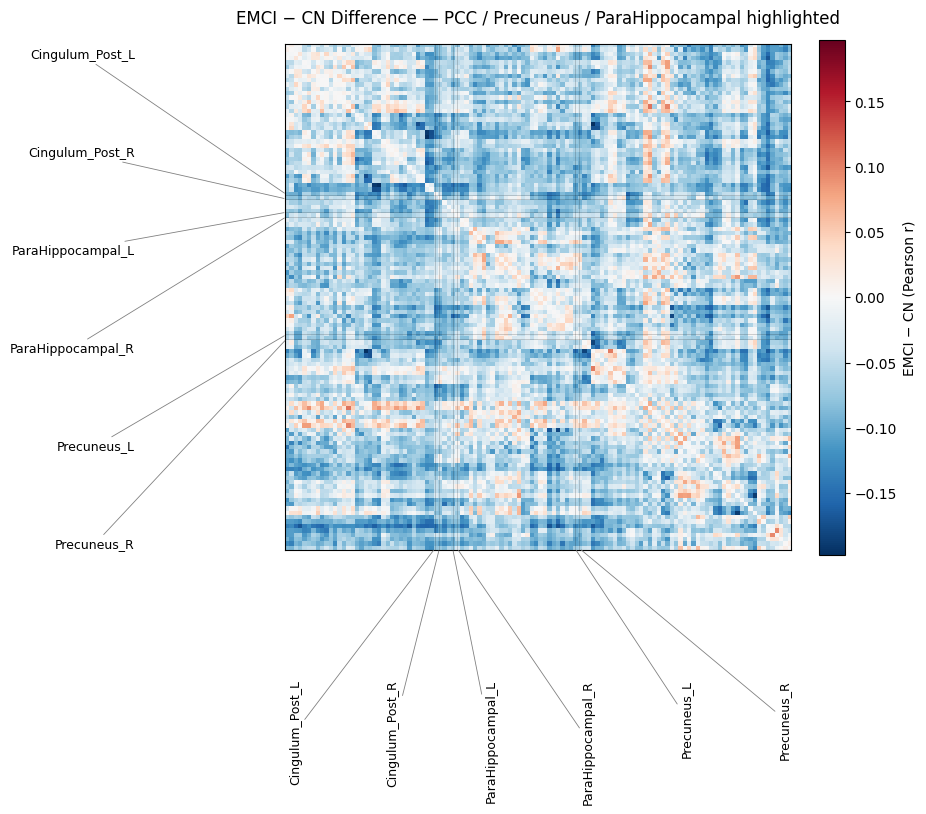

In [ ]:
# [26]
# ── Labeled diff heatmap, v2: staggered callouts with leader lines instead of
# tick labels (tick labels collide when two ROIs sit 1-2 rows apart, as
# Cingulum_Post_L/R and ParaHippocampal_L/R do here) ──────────────────────────
n = diff_mat.shape[0]
vabs = np.abs(diff_mat).max()

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(diff_mat, cmap='RdBu_r', vmin=-vabs, vmax=vabs)
plt.colorbar(im, ax=ax, fraction=0.046, label='EMCI − CN (Pearson r)')

# thin reference lines through every highlighted row/col, kept for traceability
for idx in highlight_idx:
    ax.axhline(idx, color='black', linewidth=0.4, alpha=0.3)
    ax.axvline(idx, color='black', linewidth=0.4, alpha=0.3)

# evenly-spaced callout positions so labels never collide, regardless of how
# close the underlying rows/columns actually are
label_ys = np.linspace(2, n - 2, len(highlight_idx))
for idx, name, label_y in zip(highlight_idx, highlight_names, label_ys):
    ax.annotate(
        name, xy=(0, idx), xytext=(-n * 0.30, label_y),
        ha='right', va='center', fontsize=9,
        arrowprops=dict(arrowstyle='-', lw=0.6, color='gray', shrinkA=0, shrinkB=2),
        annotation_clip=False,
    )

label_xs = np.linspace(2, n - 2, len(highlight_idx))
for idx, name, label_x in zip(highlight_idx, highlight_names, label_xs):
    ax.annotate(
        name, xy=(idx, n - 1), xytext=(label_x, n * 1.25),
        ha='center', va='top', fontsize=9, rotation=90,
        arrowprops=dict(arrowstyle='-', lw=0.6, color='gray', shrinkA=0, shrinkB=2),
        annotation_clip=False,
    )

ax.set_xticks([])
ax.set_yticks([])
ax.set_title('EMCI − CN Difference — PCC / Precuneus / ParaHippocampal highlighted', pad=15)
fig.subplots_adjust(left=0.32, bottom=0.28, right=0.88, top=0.90)
plt.savefig(f'{RESULTS_DIR}/connectivity_diff_labeled.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# [27]

# ── Added B: CN vs EMCI connectome visualization, highlighting PCC↔Precuneus ─
from scipy import ndimage
from nilearn import plotting

def atlas_column_names_and_coords(aal, atlas_img):
    """Resolve AAL column names and MNI coordinates in the same order as masker output."""
    if 'indices' in aal:
        value_to_name = {int(idx): name for idx, name in zip(aal['indices'], aal['labels'])}
    else:
        labels_list = list(aal['labels'])
        offset = 1 if str(labels_list[0]).lower() == 'background' else 0
        value_to_name = {i + 1: labels_list[i + offset] for i in range(len(labels_list) - offset)}

    img = nib.load(atlas_img) if isinstance(atlas_img, (str, Path)) else atlas_img
    arr = img.get_fdata()
    affine = img.affine
    region_values = sorted(int(v) for v in np.unique(arr) if v != 0)

    names, coords = [], []
    for v in region_values:
        names.append(value_to_name.get(v, f'Label_{v}'))
        ijk = ndimage.center_of_mass(arr == v)
        xyz = nib.affines.apply_affine(affine, ijk)
        coords.append(tuple(xyz))
    return names, np.asarray(coords), region_values

column_names, node_coords, region_values = atlas_column_names_and_coords(aal, atlas_img)

def find_roi_indices(keywords):
    return [i for i, name in enumerate(column_names)
            if any(k.lower() in name.lower() for k in keywords)]

pcc_idx       = find_roi_indices(['Cingulum_Post', 'Cingulate_Post', 'PCC'])
precuneus_idx = find_roi_indices(['Precuneus'])

print('PCC candidates      :', [(i, column_names[i]) for i in pcc_idx])
print('Precuneus candidates:', [(i, column_names[i]) for i in precuneus_idx])

# Use correlation matrices already computed in Section 9 if available; otherwise compute them.
if 'corr_matrices' not in globals():
    corr_measure  = ConnectivityMeasure(kind='correlation')
    corr_matrices = corr_measure.fit_transform(timeseries_list)

cn_mean   = corr_matrices[y == 0].mean(axis=0)
emci_mean = corr_matrices[y == 1].mean(axis=0)
diff_mat  = emci_mean - cn_mean

# Quantify PCC↔Precuneus edge strengths
edge_rows = []
highlight_edges_cn = np.zeros_like(cn_mean)
highlight_edges_emci = np.zeros_like(emci_mean)
for pi in pcc_idx:
    for qi in precuneus_idx:
        edge_rows.append({
            'PCC_ROI': column_names[pi],
            'Precuneus_ROI': column_names[qi],
            'CN_mean_r': cn_mean[pi, qi],
            'EMCI_mean_r': emci_mean[pi, qi],
            'EMCI_minus_CN': diff_mat[pi, qi],
        })
        highlight_edges_cn[pi, qi] = highlight_edges_cn[qi, pi] = cn_mean[pi, qi]
        highlight_edges_emci[pi, qi] = highlight_edges_emci[qi, pi] = emci_mean[pi, qi]

pcc_precuneus_df = pd.DataFrame(edge_rows)
display(pcc_precuneus_df.round(4))
pcc_precuneus_df.to_csv(f'{RESULTS_DIR}/pcc_precuneus_edges_cn_vs_emci.csv', index=False)

# Threshold: keep strongest absolute edges to avoid a visually unreadable hairball.
# Adjust percentile lower (e.g., 95) if you want more edges; higher (e.g., 99) for fewer.
CONNECTOME_PERCENTILE = 98

def threshold_connectome(mat, percentile=98, keep_indices=None):
    m = mat.copy()
    np.fill_diagonal(m, 0)
    tri = np.abs(m[np.triu_indices_from(m, k=1)])
    thr = np.percentile(tri, percentile)
    m[np.abs(m) < thr] = 0
    if keep_indices:
        for i, j in keep_indices:
            m[i, j] = mat[i, j]
            m[j, i] = mat[j, i]
    return m

keep_pairs = [(pi, qi) for pi in pcc_idx for qi in precuneus_idx]
cn_plot   = threshold_connectome(cn_mean, CONNECTOME_PERCENTILE, keep_pairs)
emci_plot = threshold_connectome(emci_mean, CONNECTOME_PERCENTILE, keep_pairs)

for group_name, mat, highlight_mat in [
    ('CN', cn_plot, highlight_edges_cn),
    ('EMCI', emci_plot, highlight_edges_emci),
]:
    title = (
        f'{group_name} mean functional connectome — top {100-CONNECTOME_PERCENTILE}% strongest edges\n'
        f'PCC↔Precuneus edges retained/highlighted'
    )
    display_obj = plotting.plot_connectome(
        mat,
        node_coords,
        title=title,
        display_mode='lyrz',
        node_size=18,
        edge_threshold=None,
        colorbar=True,
        edge_cmap='RdBu_r'
    )
    # Overlay PCC↔Precuneus edges in a single visible color if nilearn supports add_graph.
    try:
        display_obj.add_graph(highlight_mat, node_coords, edge_color='red', node_color='black', node_size=28)
    except Exception as e:
        print(f'Highlight overlay skipped for {group_name}: {e}')
    plotting.show()

# Difference connectome: negative edges indicate weaker EMCI connectivity than CN.
diff_plot = threshold_connectome(diff_mat, CONNECTOME_PERCENTILE, keep_pairs)
display_obj = plotting.plot_connectome(
    diff_plot,
    node_coords,
    title='EMCI − CN functional-connectivity difference\nnegative PCC↔Precuneus edges = disconnection in EMCI',
    display_mode='lyrz',
    node_size=18,
    edge_threshold=None,
    colorbar=True,
    edge_cmap='RdBu_r'
)
try:
    highlight_diff = np.zeros_like(diff_mat)
    for pi, qi in keep_pairs:
        highlight_diff[pi, qi] = highlight_diff[qi, pi] = diff_mat[pi, qi]
    display_obj.add_graph(highlight_diff, node_coords, edge_color='red', node_color='black', node_size=28)
except Exception as e:
    print(f'Difference highlight overlay skipped: {e}')
# plotting.show()/

# Compact numeric visual: PCC↔Precuneus edge values
if len(pcc_precuneus_df):
    edge_labels = [f"{r.PCC_ROI}↔{r.Precuneus_ROI}" for _, r in pcc_precuneus_df.iterrows()]
    x = np.arange(len(edge_labels))
    width = 0.38
    plt.figure(figsize=(max(8, len(edge_labels)*1.4), 4))
    plt.bar(x - width/2, pcc_precuneus_df['CN_mean_r'], width, label='CN')
    plt.bar(x + width/2, pcc_precuneus_df['EMCI_mean_r'], width, label='EMCI')
    plt.axhline(0, linewidth=0.8)
    plt.xticks(x, edge_labels, rotation=35, ha='right')
    plt.ylabel('Mean Pearson r')
    plt.title('PCC↔Precuneus connectivity: CN vs EMCI')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/pcc_precuneus_cn_emci_barplot.png', dpi=150, bbox_inches='tight')
    plt.show()


PCC candidates      : [(34, 'Cingulum_Post_L'), (35, 'Cingulum_Post_R')]
Precuneus candidates: [(66, 'Precuneus_L'), (67, 'Precuneus_R')]


,PCC_ROI,Precuneus_ROI,CN_mean_r,EMCI_mean_r,EMCI_minus_CN
0,Cingulum_Post_L,Precuneus_L,0.5892,0.4847,-0.1045
1,Cingulum_Post_L,Precuneus_R,0.5871,0.4749,-0.1122
2,Cingulum_Post_R,Precuneus_L,0.5357,0.4272,-0.1085
3,Cingulum_Post_R,Precuneus_R,0.5599,0.4839,-0.0760


Highlight overlay skipped for CN: OrthoProjector.add_graph() got an unexpected keyword argument 'edge_color'. Did you mean 'node_color'?


## 9 · Results summary

In [ ]:
# [28]
# Registration-pathway breakdown — LEAKAGE-FREE (tangent refit per fold).
# NOTE: recomputes Table II per fold instead of on the full-cohort X, so these
# numbers may differ slightly from the earlier leaky version — expected, and the
# same correction applied everywhere else in the notebook.
if COL_METHOD in cohort_final.columns:
    methods = cohort_final[COL_METHOD].values
    print(f'{"Method":<20}{"n":>6}{"Balanced acc. (leak-free)":>28}')
    print('-' * 54)
    for m in sorted(set(methods)):
        idx_m = np.where(methods == m)[0]
        y_m   = y[idx_m]
        if len(np.unique(y_m)) < 2 or int(min(np.bincount(y_m))) < CV_FOLDS:
            print(f'{m:<20}{len(idx_m):>6}{"  (too few/imbalanced for CV)":>28}')
            continue
        k     = min(CV_FOLDS, int(min(np.bincount(y_m))))
        skf_m = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
        ts_m  = [timeseries_list[i] for i in idx_m]
        fold_bals = []
        for tr, te in skf_m.split(np.zeros(len(y_m)), y_m):
            cm = ConnectivityMeasure(kind='tangent', vectorize=True, discard_diagonal=True)
            cm.fit([ts_m[i] for i in tr])
            X_tr = cm.transform([ts_m[i] for i in tr])
            X_te = cm.transform([ts_m[i] for i in te])
            clf = LinearSVC(class_weight='balanced', random_state=SEED, max_iter=10000)
            clf.fit(X_tr, y_m[tr])
            fold_bals.append(balanced_accuracy_score(y_m[te], clf.predict(X_te)))
        fold_bals = np.array(fold_bals)
        print(f'{m:<20}{len(idx_m):>6}{f"{fold_bals.mean():.3f} +/- {fold_bals.std():.3f}":>28}')
else:
    print(f'Column "{COL_METHOD}" not present in cohort_final — skipping breakdown.')


In [ ]:
# [29]
results_summary = {
    'pipeline': {
        'registration'  : 'ANTs, MNI152 2mm (STEP1, external to this notebook)',
        'quality_filter': f'centroid-offset QC, tiers={QUALIFYING_TIERS}',
        'atlas'         : f'AAL ({ATLAS_VERSION}), {n_real_regions} regions',
        'connectivity'  : 'tangent (classification) / correlation (descriptive only)',
        'classifier'    : 'LinearSVC(class_weight="balanced")',
        'bandpass'      : f'{HIGH_PASS}-{LOW_PASS} Hz',
        'max_volumes'   : MAX_VOLUMES,
        'dummy_scans'   : DUMMY_SCANS,
    },
    'cohort': {
        'n_subjects' : int(len(cohort_final)),
        'n_cn'       : int((y == 0).sum()),
        'n_emci'     : int((y == 1).sum()),
        'n_features' : int(X.shape[1]),
    },
    'results': {
        'primary_leakage_free': {
            'nested_cv_balanced_accuracy_mean': round(float(nested_cv_scores.mean()), 4),
            'nested_cv_balanced_accuracy_std' : round(float(nested_cv_scores.std()), 4),
            'seed_stability_mean'             : round(float(nested_seed_means.mean()), 4),
            'seed_stability_std'              : round(float(nested_seed_means.std()), 4),
            'repeated_holdout_mean'           : round(float(repeat_bal_accs.mean()), 4),
            'site_aware_cv_mean'              : round(float(per_repeat_means.mean()), 4),
        },
        'secondary_leakage_affected': {
            'full_cohort_cv_balanced_accuracy_mean': round(float(cv_scores.mean()), 4),
            'full_cohort_cv_balanced_accuracy_std' : round(float(cv_scores.std()), 4),
        },
        'permutation_score'  : round(float(score), 4),
        'permutation_pvalue' : round(float(pvalue), 4),
    },
    'created_at': datetime.now().isoformat(),
}

with open(f'{RESULTS_DIR}/final_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print('Results saved to:', f'{RESULTS_DIR}/final_results.json')
print(json.dumps(results_summary, indent=2))

NameError: name 'cv_scores' is not defined

## 10 · Random Forest classifier

Evaluates a **Random Forest** under the *same* two leakage-free protocols used for the LinearSVC baseline, so the two models are directly comparable:

- **Repeated holdout** (random 80/20 splits) — mirrors Section 5.
- **Repeated site-aware CV** (whole sites held out) — mirrors Section 7.

The tangent reference is refit inside every split/fold (train-only). Balanced accuracy is the anchor metric; sensitivity, specificity, F1 and AUC are reported alongside it. A native RF feature-importance ranking is added for interpretation.

> Expectation: connectivity features are *p ≫ n* here (6,670 features, 433 subjects) with a faint effect (d ≈ 0.4). Tree ensembles usually sit **at or below** linear models in this regime — so read RF as a robustness check on the LinearSVC result, not a route to a higher ceiling.


In [ ]:
# [30]
# ── Shared metrics helper: sensitivity, specificity, F1, AUC, balanced acc ────
# Balanced accuracy alone hides which way errors run. For an early-detection task
# the clinically meaningful pair is sensitivity (EMCI correctly caught) and
# specificity (CN correctly cleared). We add F1 and AUC-ROC for completeness and
# threshold-independent ranking. This helper is reused by the classifier table.
from sklearn.metrics import (balanced_accuracy_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

def full_metrics(y_true, y_pred, y_score=None):
    """Return a dict of metrics. y_score (decision function / proba) enables AUC."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan   # recall for EMCI (class 1)
    specificity = tn / (tn + fp) if (tn + fp) else np.nan   # recall for CN (class 0)
    m = {
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
        'sensitivity':  sensitivity,          # true positive rate (EMCI)
        'specificity':  specificity,          # true negative rate (CN)
        'f1':           f1_score(y_true, y_pred, pos_label=1),
    }
    m['auc'] = roc_auc_score(y_true, y_score) if y_score is not None else np.nan
    return m

print('✓ full_metrics() defined (balanced_acc, sensitivity, specificity, f1, auc).')


In [ ]:
# [31]
# ── Random Forest — leakage-free repeated holdout ────────────────────────────
# Same honest protocol as Section 5's LinearSVC result: many random stratified
# 80/20 splits, tangent reference refit on each split's TRAINING subjects only,
# Random Forest trained and scored on the held-out test set. Reported with the
# full clinical metric set so RF is directly comparable to the LinearSVC number.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

RF_N_ESTIMATORS = 400        # shared by every RF fit + the final comparison table
RF_N_REPEATS    = 20         # random splits to average over (matches Section 5)

rf_holdout_metrics = []      # one full_metrics dict per repeat

for rep in range(RF_N_REPEATS):
    rep_seed = SEED + rep
    try:
        tr_idx, te_idx = train_test_split(
            indices, test_size=TEST_SIZE, random_state=rep_seed, stratify=strat_key)
    except ValueError:
        tr_idx, te_idx = train_test_split(
            indices, test_size=TEST_SIZE, random_state=rep_seed, stratify=y)

    tr_ts = [timeseries_list[i] for i in tr_idx]
    te_ts = [timeseries_list[i] for i in te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    # leakage-free features: tangent reference fit on the training split only
    cm = ConnectivityMeasure(kind='tangent', vectorize=True, discard_diagonal=True)
    cm.fit(tr_ts)
    X_tr, X_te = cm.transform(tr_ts), cm.transform(te_ts)

    rf = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, class_weight='balanced',
                                random_state=rep_seed, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred  = rf.predict(X_te)
    y_score = rf.predict_proba(X_te)[:, 1]
    rf_holdout_metrics.append(full_metrics(y_te, y_pred, y_score))

# aggregate mean ± std across repeats for every metric
rf_hold = {k: np.array([m[k] for m in rf_holdout_metrics]) for k in rf_holdout_metrics[0]}

print('RANDOM FOREST — leakage-free repeated holdout')
print(f'{RF_N_REPEATS} random 80/20 splits, tangent refit per split (train-only)')
print('=' * 60)
for k, lbl in [('balanced_acc', 'Balanced accuracy'), ('sensitivity', 'Sensitivity (EMCI)'),
               ('specificity', 'Specificity (CN)'), ('f1', 'F1'), ('auc', 'AUC')]:
    print(f'  {lbl:<22}: {rf_hold[k].mean():.3f} ± {rf_hold[k].std():.3f}')

print('\nContext (balanced accuracy, same protocol):')
print(f'  LinearSVC (Section 5)    : 0.711 ± 0.049')
print(f'  RandomForest (this cell) : {rf_hold["balanced_acc"].mean():.3f} ± {rf_hold["balanced_acc"].std():.3f}')

plt.figure(figsize=(7, 4))
plt.hist(rf_hold['balanced_acc'], bins=12, color='#2E7D32', edgecolor='white')
plt.axvline(0.5, color='gray', ls='--', lw=1.5, label='Chance (0.5)')
plt.axvline(rf_hold['balanced_acc'].mean(), color='crimson', lw=2,
            label=f'Mean = {rf_hold["balanced_acc"].mean():.3f}')
plt.xlabel('Balanced accuracy (held-out test)'); plt.ylabel('Count')
plt.title(f'Random Forest — repeated holdout ({RF_N_REPEATS} splits)')
plt.legend(); plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/rf_repeated_holdout.png', dpi=150, bbox_inches='tight')
plt.show()

np.savez(f'{OUTPUT_DIR}/rf_repeated_holdout.npz',
         n_repeats=RF_N_REPEATS, n_estimators=RF_N_ESTIMATORS,
         **{k: v for k, v in rf_hold.items()})
print(f'\n✓ Saved: {OUTPUT_DIR}/rf_repeated_holdout.npz')


In [ ]:
# [32]
# ── Random Forest — repeated site-aware CV ───────────────────────────────────
# Same protocol as Section 7: StratifiedGroupKFold (whole sites held out per
# fold), tangent reference refit on the TRAINING sites only, repeated over many
# seeds and pooled. This is the generalization-to-unseen-scanners number for RF,
# directly comparable to the LinearSVC 0.653 site-aware result.
from sklearn.model_selection import StratifiedGroupKFold

RF_CV_REPEATS = 20
rf_seeds = np.arange(RF_CV_REPEATS) + SEED

rf_fold_metrics   = []   # full_metrics dict per fold (pooled across all repeats)
rf_per_repeat_bal = []   # per-repeat mean balanced accuracy

print('RANDOM FOREST — repeated site-aware CV')
print(f'StratifiedGroupKFold, {CV_FOLDS} folds x {RF_CV_REPEATS} repeats '
      f'= {CV_FOLDS * RF_CV_REPEATS} held-out-site evaluations')
print('=' * 62)

for r, rs in enumerate(rf_seeds):
    sgkf = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=int(rs))
    repeat_bal = []
    for tr_idx, te_idx in sgkf.split(X, y, groups=site_groups):
        tr_ts = [timeseries_list[i] for i in tr_idx]
        te_ts = [timeseries_list[i] for i in te_idx]
        cm = ConnectivityMeasure(kind='tangent', vectorize=True, discard_diagonal=True)
        cm.fit(tr_ts)
        X_tr, X_te = cm.transform(tr_ts), cm.transform(te_ts)

        rf = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, class_weight='balanced',
                                    random_state=int(rs), n_jobs=-1)
        rf.fit(X_tr, y[tr_idx])
        y_pred  = rf.predict(X_te)
        y_score = rf.predict_proba(X_te)[:, 1]
        m = full_metrics(y[te_idx], y_pred, y_score)
        rf_fold_metrics.append(m)
        repeat_bal.append(m['balanced_acc'])
    rf_per_repeat_bal.append(np.mean(repeat_bal))
    print(f'  repeat {r:2d} (seed {int(rs):3d}): mean bal_acc={np.mean(repeat_bal):.3f}')

rf_per_repeat_bal = np.array(rf_per_repeat_bal)
rf_site = {k: np.array([m[k] for m in rf_fold_metrics]) for k in rf_fold_metrics[0]}

print('\n' + '=' * 62)
print('SUMMARY (pooled over all folds)')
print('=' * 62)
for k, lbl in [('balanced_acc', 'Balanced accuracy'), ('sensitivity', 'Sensitivity (EMCI)'),
               ('specificity', 'Specificity (CN)'), ('f1', 'F1'), ('auc', 'AUC')]:
    print(f'  {lbl:<22}: {rf_site[k].mean():.3f} ± {rf_site[k].std():.3f}')
print(f'\n  Mean of per-repeat means : {rf_per_repeat_bal.mean():.3f} ± {rf_per_repeat_bal.std():.3f}')

print('\nContext (site-aware balanced accuracy):')
print(f'  LinearSVC (Section 7)    : 0.653 ± 0.023')
print(f'  RandomForest (this cell) : {rf_per_repeat_bal.mean():.3f} ± {rf_per_repeat_bal.std():.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rf_site['balanced_acc'], bins=20, color='#8FB9C7', edgecolor='white')
ax.axvline(rf_site['balanced_acc'].mean(), color='crimson', lw=2,
           label=f'Mean = {rf_site["balanced_acc"].mean():.3f}')
ax.axvline(0.5, color='gray', ls='--', lw=1.5, label='Chance')
ax.set_xlabel('Individual fold balanced accuracy'); ax.set_ylabel('Count')
ax.set_title(f'RF site-aware CV — all {len(rf_site["balanced_acc"])} folds')
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/rf_site_aware_cv.png', dpi=150, bbox_inches='tight')
plt.show()

np.savez(f'{OUTPUT_DIR}/rf_site_aware_cv.npz',
         per_repeat_means=rf_per_repeat_bal,
         n_repeats=RF_CV_REPEATS, n_folds=CV_FOLDS, n_estimators=RF_N_ESTIMATORS,
         **{f'fold_{k}': v for k, v in rf_site.items()})
print(f'\n✓ Saved: {OUTPUT_DIR}/rf_site_aware_cv.npz')


In [ ]:
# [33]
# ── Random Forest — top connectivity features (interpretive) ─────────────────
# RF gives a native feature-importance ranking that LinearSVC does not. It is fit
# once on the full-cohort tangent features purely to SEE which region-pair
# connections it leans on -- this is INTERPRETATION, not a performance estimate
# (performance is the leakage-free numbers above). Each feature is mapped back to
# its AAL region pair, and we check whether the top connections overlap the DMN
# disconnection story (PCC / Precuneus) confirmed in Section 8.
from sklearn.ensemble import RandomForestClassifier

# Map each vectorized tangent feature back to its (i, j) region pair. nilearn's
# vectorize=True + discard_diagonal=True flattens the strict lower triangle in
# row-major order, i.e. (i, j) for i in range(N), j in range(i).
N_ROI = len(column_names)
pair_index = [(i, j) for i in range(N_ROI) for j in range(i)]
assert len(pair_index) == X.shape[1], (
    f'pair count {len(pair_index)} != n_features {X.shape[1]} -- check ROI count')

rf_full = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, class_weight='balanced',
                                 random_state=SEED, n_jobs=-1)
rf_full.fit(X, y)
importances = rf_full.feature_importances_

TOP_N = 20
top = np.argsort(importances)[::-1][:TOP_N]

print(f'TOP {TOP_N} connectivity features by Random Forest importance')
print('(fit on full cohort -- interpretive only, not a performance number)')
print('=' * 70)
rows_imp = []
for rank, k in enumerate(top, 1):
    i, j = pair_index[k]
    a, b = column_names[i], column_names[j]
    rows_imp.append({'rank': rank, 'region_A': a, 'region_B': b,
                     'importance': float(importances[k])})
    print(f'  {rank:2d}. {a:<22} <-> {b:<22}  imp={importances[k]:.5f}')

imp_df = pd.DataFrame(rows_imp)
imp_df.to_csv(f'{OUTPUT_DIR}/rf_feature_importance_top.csv', index=False)

# flag any top features that touch the DMN nodes examined in Section 8
dmn_kw = ['cingulum_post', 'precuneus', 'parahippocampal']
dmn_hits = [r for r in rows_imp
            if any(kw in (r['region_A'] + r['region_B']).lower() for kw in dmn_kw)]
print(f'\nTop-{TOP_N} features touching DMN nodes (PCC / Precuneus / ParaHip): {len(dmn_hits)}')
for r in dmn_hits:
    print(f'  rank {r["rank"]:2d}: {r["region_A"]} <-> {r["region_B"]}')

plt.figure(figsize=(8, 6))
ypos = np.arange(TOP_N)[::-1]
plt.barh(ypos, importances[top], color='#2E7D32')
plt.yticks(ypos, [f'{column_names[pair_index[k][0]]} <-> {column_names[pair_index[k][1]]}'
                  for k in top], fontsize=7)
plt.xlabel('Random Forest importance'); plt.title(f'Top {TOP_N} connections (RF)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✓ Saved: {OUTPUT_DIR}/rf_feature_importance_top.csv')


## 11 · Classifier comparison — all models

Consolidated head-to-head of every classifier (LinearSVC, Logistic Regression-L2, Ridge, SVM-RBF, **Random Forest**) under one identical leakage-free protocol — tangent reference refit per fold, standard stratified CV so the split is held fixed and only the model varies. Full clinical metric set (balanced accuracy, sensitivity, specificity, F1, AUC). This is the final table for the manuscript.


In [ ]:
# [34]
# ── FINAL classifier comparison table (leakage-free CV, full metric set) ──────
# Compares five classifiers under an IDENTICAL leakage-free protocol: tangent
# reference refit on the training fold, then the model. The point is defensive,
# not exploratory — prior work established linear models win in this p>>n regime;
# this table shows the RESULT does not depend on classifier choice. Standard
# stratified CV is used (not site-aware) so the comparison isolates the effect of
# the model, holding the split protocol fixed.
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.base import clone

# Each classifier + a helper to get a continuous score for AUC.
classifiers = {
    'LinearSVC':          LinearSVC(class_weight='balanced', random_state=SEED, max_iter=10000),
    'LogisticReg (L2)':   LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED),
    'Ridge':              RidgeClassifier(class_weight='balanced', random_state=SEED),
    'SVM-RBF':            SVC(kernel='rbf', class_weight='balanced', random_state=SEED),
    'RandomForest':       RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, class_weight='balanced', random_state=SEED),
}

def get_scores(clf, X_te):
    """Continuous scores for AUC: proba if available, else decision_function."""
    if hasattr(clf, 'predict_proba'):
        return clf.predict_proba(X_te)[:, 1]
    if hasattr(clf, 'decision_function'):
        return clf.decision_function(X_te)
    return None

cv_tab = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

rows = []
print('CLASSIFIER COMPARISON (leakage-free tangent per fold)')
print('=' * 68)
for name, base_clf in classifiers.items():
    fold_metrics = []
    for tr_idx, te_idx in cv_tab.split(X, y):
        # leakage-free features: tangent reference on training fold only
        tr_ts = [timeseries_list[i] for i in tr_idx]
        te_ts = [timeseries_list[i] for i in te_idx]
        cm = ConnectivityMeasure(kind='tangent', vectorize=True, discard_diagonal=True)
        cm.fit(tr_ts)
        X_tr, X_te = cm.transform(tr_ts), cm.transform(te_ts)

        clf = clone(base_clf)
        clf.fit(X_tr, y[tr_idx])
        y_pred  = clf.predict(X_te)
        y_score = get_scores(clf, X_te)
        fold_metrics.append(full_metrics(y[te_idx], y_pred, y_score))

    agg = {k: np.mean([fm[k] for fm in fold_metrics]) for k in fold_metrics[0]}
    agg_std = {k: np.std([fm[k] for fm in fold_metrics]) for k in fold_metrics[0]}
    rows.append({'classifier': name, **agg, **{f'{k}_std': v for k, v in agg_std.items()}})
    print(f'  {name:18s}: bal_acc={agg["balanced_acc"]:.3f}  '
          f'sens={agg["sensitivity"]:.3f}  spec={agg["specificity"]:.3f}  '
          f'f1={agg["f1"]:.3f}  auc={agg["auc"]:.3f}')

clf_table = pd.DataFrame(rows).set_index('classifier')

# Clean display table: metric ± std
disp = pd.DataFrame(index=clf_table.index)
for k, lbl in [('balanced_acc','Balanced Acc'), ('sensitivity','Sensitivity'),
               ('specificity','Specificity'), ('f1','F1'), ('auc','AUC')]:
    disp[lbl] = clf_table.apply(lambda r: f'{r[k]:.3f} ± {r[f"{k}_std"]:.3f}', axis=1)

print('\n' + '=' * 68)
print('SUMMARY TABLE (mean ± std across folds)')
print('=' * 68)
print(disp.to_string())

clf_table.to_csv(f'{OUTPUT_DIR}/classifier_comparison.csv')
print(f'\n✓ Saved: {OUTPUT_DIR}/classifier_comparison.csv')

# Grouped bar plot of balanced accuracy with AUC overlaid
fig, ax = plt.subplots(figsize=(9, 4.5))
xp = np.arange(len(clf_table))
ax.bar(xp - 0.2, clf_table['balanced_acc'], width=0.4, color='#1C7293',
       yerr=clf_table['balanced_acc_std'], capsize=3, label='Balanced accuracy')
ax.bar(xp + 0.2, clf_table['auc'], width=0.4, color='#E0A458',
       yerr=clf_table['auc_std'], capsize=3, label='AUC')
ax.axhline(0.5, color='gray', ls='--', lw=1.5, label='Chance')
ax.set_xticks(xp); ax.set_xticklabels(clf_table.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score'); ax.set_ylim(0.4, 0.85)
ax.set_title('Classifier comparison (leakage-free CV)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 9 · Prior-method re-implementation — optimistic vs leakage-free (Reviewer #5, Item 10)

Re-implements a **representative high-accuracy prior pipeline** — graph-theoretic
connectivity features + a neural-network classifier, the family used by the
94.55% study [1] — on **this** 432-subject cohort, under two evaluation
protocols that differ in **one** thing only: whether feature selection is
allowed to see the whole dataset.

* **Optimistic** — feature selection fit once on all subjects, then CV
  (the small-cohort recipe that inflates estimates).
* **Rigorous** — identical features/classifier, but selection re-fit **inside
  each training fold** (leakage-free, matching the rest of this notebook).

If the optimistic score inflates and the rigorous score regresses toward our
~0.65–0.71 range, that is direct evidence the accuracy gap with prior work is
driven by **evaluation rigor, not a weaker signal** in our pipeline.

*Runtime: minutes. Checkpoints after each stage to Drive so it is resumable.*

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# 9 · P4 — graph-theoretic features + MLP, optimistic vs leakage-free
#     Representative of Zamani et al. [1]'s feature family + classifier.
#     Checkpointed + resumable: re-running skips finished stages.
# ─────────────────────────────────────────────────────────────────────────
import os, numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone
from nilearn.connectome import ConnectivityMeasure

# --- config -----------------------------------------------------------------
P4_K_FEATURES = 50          # features kept by selection (Zamani-style reduction)
P4_SEED       = SEED
P4_CKPT       = f'{OUTPUT_DIR}/p4_graph_features.npy'
P4_RESULT     = f'{RESULTS_DIR}/p4_prior_method.json'

# --- 1. graph-theoretic features (per subject) — the slow part, cached -------
def _graph_features(corr, densities=(0.10, 0.20, 0.30)):
    """Nodal graph metrics across a few edge densities -> 1-D feature vector.
    Uses bctpy if available; falls back to numpy-only equivalents otherwise."""
    C = np.abs(np.asarray(corr, float)).copy()
    np.fill_diagonal(C, 0.0)
    feats = []
    try:
        import bct
        for d in densities:
            W = bct.threshold_proportional(C, d)
            L = bct.weight_conversion(W, 'lengths')
            feats += [bct.strengths_und(W),
                      bct.clustering_coef_wu(W),
                      bct.betweenness_wei(L),
                      bct.efficiency_wei(W, local=True),
                      [bct.efficiency_wei(W)]]
    except Exception as e:
        # numpy fallback: strength + weighted clustering + a global-efficiency proxy
        print(f'  [bct unavailable -> numpy fallback: {type(e).__name__}]')
        n = C.shape[0]
        for d in densities:
            k = max(1, int(d * n * (n - 1) / 2))
            thr = np.sort(C[np.triu_indices(n, 1)])[::-1][k - 1]
            W = np.where(C >= thr, C, 0.0)
            s = W.sum(1)
            # weighted clustering coefficient (Onnela)
            tri = np.zeros(n)
            Wc = W ** (1 / 3)
            for i in range(n):
                tri[i] = (Wc[i][:, None] * Wc * Wc[i]).sum()  # crude triangle proxy
            deg = (W > 0).sum(1)
            cc = np.divide(tri, (deg * (deg - 1)), out=np.zeros(n), where=deg > 1)
            geff = (1.0 / np.where(W > 0, 1.0 / (W + 1e-12), np.inf)).sum() / (n * (n - 1))
            feats += [s, cc, [geff]]
    return np.concatenate([np.ravel(f) for f in feats])

if os.path.exists(P4_CKPT):
    X_graph = np.load(P4_CKPT)
    print(f'✓ Loaded cached graph features: {X_graph.shape}')
else:
    # correlation matrices from the SAME timeseries used everywhere else
    corr_measure_p4 = ConnectivityMeasure(kind='correlation', vectorize=False)
    corr_mats = corr_measure_p4.fit_transform(timeseries_list)   # (n, 116, 116)
    X_graph = np.vstack([_graph_features(c) for c in corr_mats])
    np.save(P4_CKPT, X_graph)
    print(f'✓ Built + cached graph features: {X_graph.shape}  ->  {P4_CKPT}')

# --- 2. classifier (Zamani-style ANN) ---------------------------------------
mlp = MLPClassifier(hidden_layer_sizes=(64,), alpha=1e-3,
                    max_iter=500, random_state=P4_SEED)
cv  = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=P4_SEED)

# --- 3a. OPTIMISTIC: feature selection on the WHOLE dataset, then CV (leaky) -
X_sel = SelectKBest(f_classif, k=min(P4_K_FEATURES, X_graph.shape[1])
                    ).fit_transform(X_graph, y)
opt_scores = cross_val_score(clone(mlp), X_sel, y, cv=cv,
                             scoring='balanced_accuracy', n_jobs=-1)

# --- 3b. RIGOROUS: identical, but selection re-fit INSIDE each fold ----------
rig_pipe = Pipeline([('scale',  StandardScaler()),
                     ('select', SelectKBest(f_classif,
                                 k=min(P4_K_FEATURES, X_graph.shape[1]))),
                     ('clf',    clone(mlp))])
rig_scores = cross_val_score(rig_pipe, X_graph, y, cv=cv,
                             scoring='balanced_accuracy', n_jobs=-1)

# --- 4. report + save -------------------------------------------------------
opt_m, opt_s = opt_scores.mean(), opt_scores.std()
rig_m, rig_s = rig_scores.mean(), rig_scores.std()
our_primary  = float(PRIMARY_RESULTS['primary_nested_cv']['balanced_acc_mean']) \
               if 'PRIMARY_RESULTS' in dir() else float('nan')

print('\nPRIOR-METHOD RE-IMPLEMENTATION (graph features + MLP, this cohort)')
print('=' * 66)
print(f'  Optimistic (leaky feature selection) : {opt_m:.3f} +/- {opt_s:.3f}')
print(f'  Rigorous   (nested feature selection): {rig_m:.3f} +/- {rig_s:.3f}')
print(f'  Inflation removed by rigor           : {opt_m - rig_m:+.3f}')
print(f'  Our tangent+SVM primary (nested CV)  : {our_primary:.3f}')
print()
if opt_m - rig_m > 0.03:
    print('  -> Optimistic protocol inflates; rigorous regresses toward our range.')
    print('     Supports: the accuracy gap reflects EVALUATION RIGOR, not signal.')
else:
    print('  -> Inflation modest on this method; report the observed numbers as-is')
    print('     and lean on cohort-scale + convergent validation for the argument.')

import json as _json
with open(P4_RESULT, 'w') as f:
    _json.dump({'optimistic_mean': float(opt_m), 'optimistic_std': float(opt_s),
                'rigorous_mean':   float(rig_m), 'rigorous_std':   float(rig_s),
                'inflation':       float(opt_m - rig_m),
                'our_primary_nested_cv': our_primary,
                'k_features': int(P4_K_FEATURES)}, f, indent=2)
print(f'\n✓ Saved: {P4_RESULT}')
